In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Health Insurance Dataset
df = pd.read_csv(r"C:\Users\Given\Downloads\Health Insurance Cleaned.csv", sep=";")

# Exploritory Data Analysis

In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 82 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Personal_Code                                   16000 non-null  float64
 1   Days_Visited_Two_Hospitals                      16000 non-null  int64  
 2   Months_Visited                                  16000 non-null  int64  
 3   Max_Monthly_Visit_Days                          16000 non-null  int64  
 4   Avg_Monthly_Visit_Days                          16000 non-null  float64
 5   Max_Monthly_Hospitals_Visited                   16000 non-null  int64  
 6   Avg_Monthly_Hospitals_Visited                   16000 non-null  float64
 7   Total_Visits                                    16000 non-null  int64  
 8   Max_Monthly_Visits                              16000 non-null  int64  
 9   Avg_Monthly_Visits      

<span style="font-size:22px;">The Dataset has 82 variables, of which 81 are the predictors with n = 16 000</span>

In [4]:
display(df.head())

,Personal_Code,Days_Visited_Two_Hospitals,Months_Visited,Max_Monthly_Visit_Days,Avg_Monthly_Visit_Days,Max_Monthly_Hospitals_Visited,Avg_Monthly_Hospitals_Visited,Total_Visits,Max_Monthly_Visits,Avg_Monthly_Visits,...,Drug_Cost_Percentage,Personal_Payment_Drug_Percentage,Examination_Cost_Percentage,Personal_Payment_Examination_Percentage,Treatment_Cost_Percentage,Personal_Payment_Treatment_Percentage,Civil_Affairs_Assistance,Urban_Rural_Preferential_Support,Registered,Result
0,352120000000000.00,0,6,7,5.67,3,2.17,34,7,5.67,...,0.94,0.00,0.05,0.00,0.01,0.00,0,0,1,0
1,352120000000000.00,0,6,4,2.50,2,1.33,15,4,2.50,...,0.96,0.00,0.03,0.00,0.01,0.00,0,0,1,0
2,352120000000000.00,8,6,8,6.17,3,2.17,45,9,7.50,...,0.78,0.00,0.00,0.00,0.20,0.00,0,0,0,0
3,352120000000000.00,0,6,6,3.67,2,1.83,23,6,3.83,...,0.46,0.00,0.00,0.00,0.54,0.00,0,0,0,0
4,352120000000000.00,0,6,5,4.33,1,1.00,26,5,4.33,...,0.98,0.00,0.00,0.00,0.02,0.00,0,0,0,0


## 1. Checking for Multicolinearinty

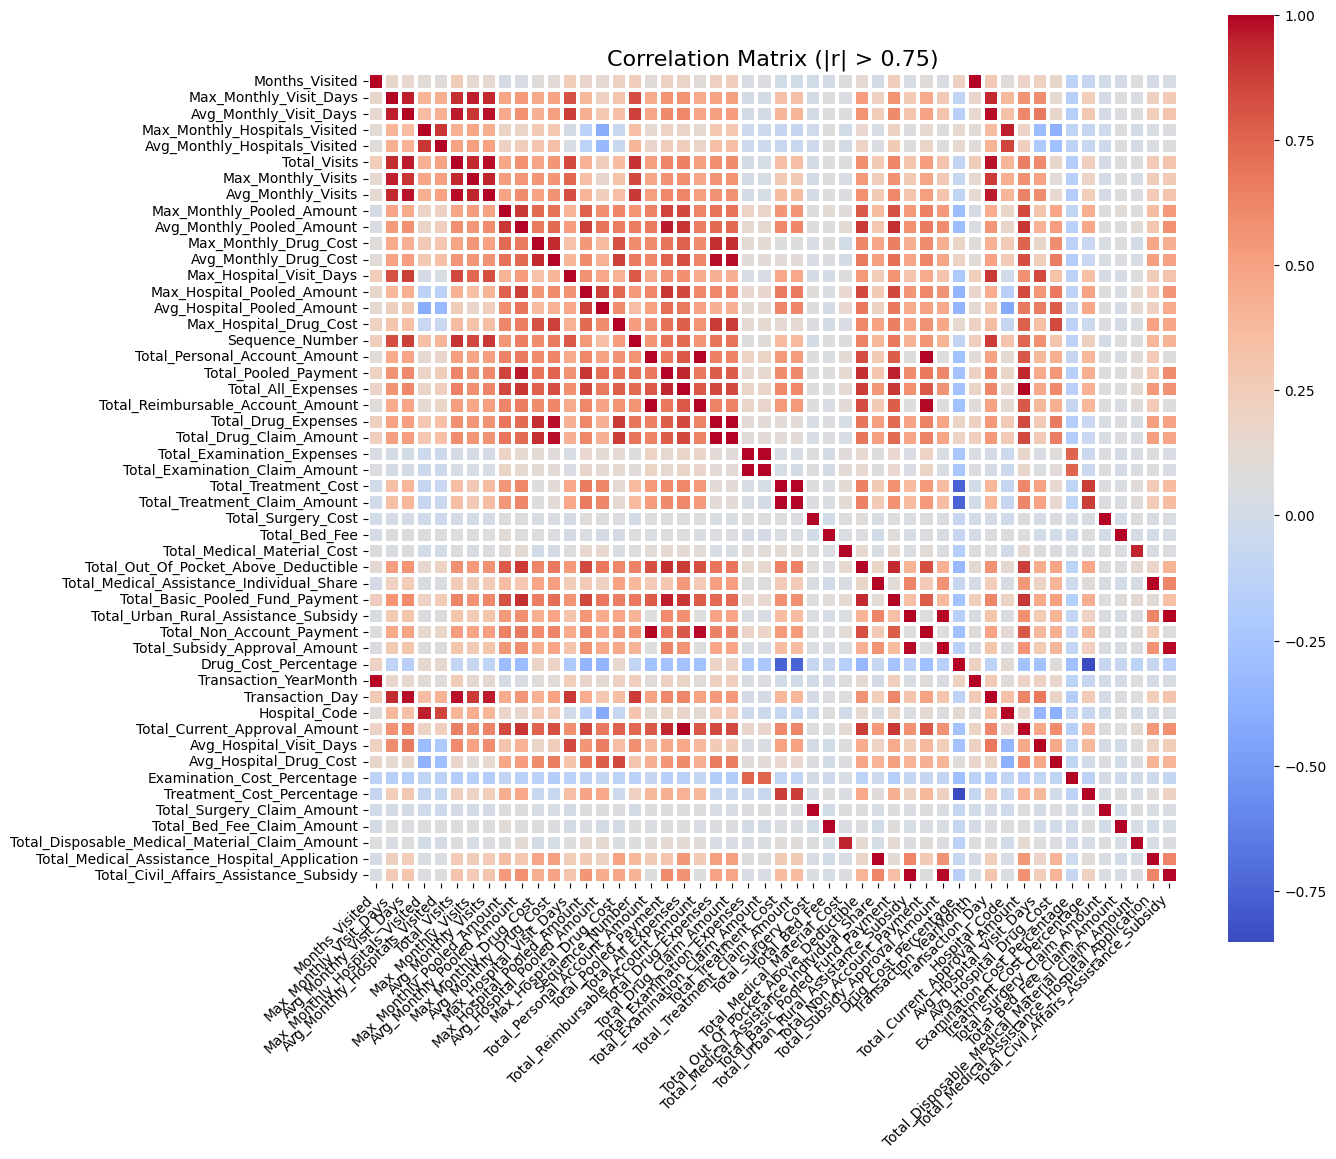

In [5]:
correlation_matrix = df.corr()
threshold = 0.75

upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={0: "Correlation", "level_0": "Feature1", "level_1": "Feature2"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > threshold]
high_corr_vars = pd.unique(high_corr_pairs[["Feature1", "Feature2"]].values.ravel("K"))
subset_corr_matrix = correlation_matrix.loc[high_corr_vars, high_corr_vars]

plt.figure(figsize=(14, 12))
sns.heatmap(
    subset_corr_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=1.5,
    cbar=True,
    square=True
)
plt.title("Correlation Matrix (|r| > 0.75)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

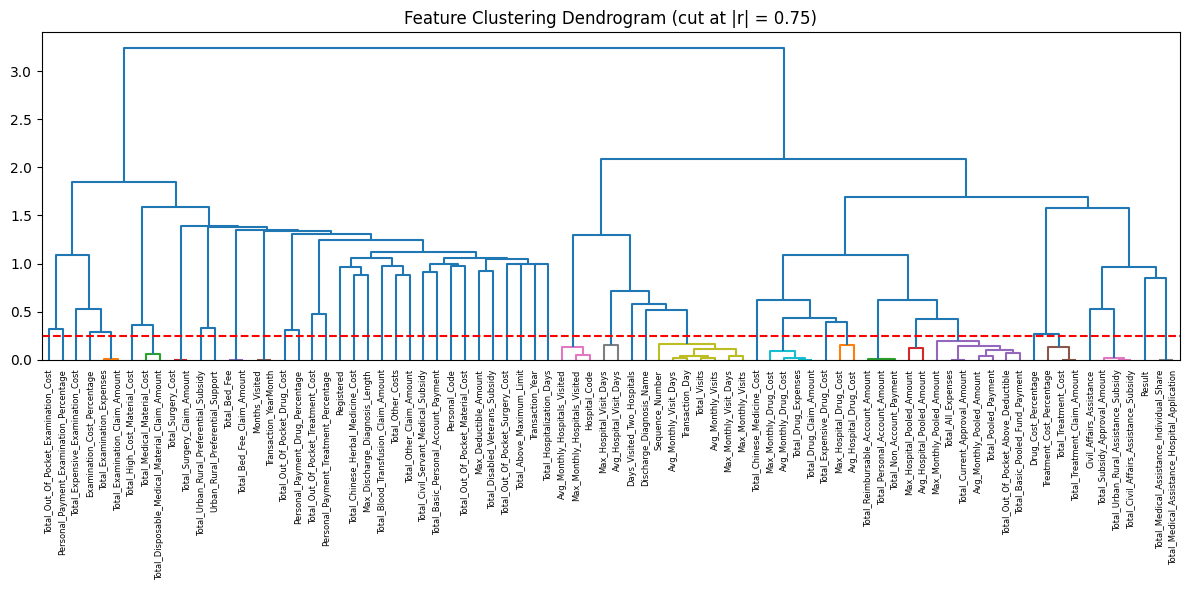

In [6]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

corr = df.corr().fillna(0)
distance_matrix = 1 - abs(corr)
condensed_dist = squareform(distance_matrix, checks=False)

plt.figure(figsize=(12, 6))
dend = sch.linkage(condensed_dist, method='ward')
sch.dendrogram(
    dend,
    labels=corr.columns,
    leaf_rotation=90,
    color_threshold=0.25   # corresponds to |r| = 0.75
)
plt.axhline(y=0.25, color='red', linestyle='--')  # cut line
plt.title("Feature Clustering Dendrogram (cut at |r| = 0.75)")
plt.tight_layout()
plt.show()

### 1.1. Checking for correlation with a threshold of |r|>0.75

In [7]:
corr_matrix = df.corr().abs()
high_corr_vars = [(i, j, corr_matrix.loc[i, j]) 
                  for i in corr_matrix.columns 
                  for j in corr_matrix.columns 
                  if i != j and corr_matrix.loc[i, j] > 0.75]

print("\nHighly Correlated Variables (Threshold > 0.75):")
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    print(f"{var1} - {var2}: {corr:.2f}")


Highly Correlated Variables (Threshold > 0.75):
Months_Visited - Transaction_YearMonth: 1.00
Transaction_YearMonth - Months_Visited: 1.00
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00
Total_Medical_Assistance_Hospital_Application - Total_Medical_Assistance_Individual_Share: 1.00
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00
Total_Treatment_Claim_Amount - Total_Treatment_Cost: 1.00
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00
Total_Drug_Claim_Amount - Total_Drug_Expenses: 1.00
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00
Total_Bed_Fee_Claim_Amount - Total_Bed_Fee: 1.00
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00
Total_Surgery_Claim_Amount - Total_Surgery_Cost: 1.00
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00
Total_Civil_Affairs_Assistance_Subsidy - Total_Urban_Rural_Assistance_Subsidy: 1.00
Total_All_Expenses - Total_Current_Approval_Amount: 1.00
Total_Current_Appr

## 2. Removing one variable from each highly correlated pair

In [8]:
removed_features = set()
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    if var1 not in removed_features and var2 not in removed_features:
        print(f"{var1} - {var2}: {corr:.2f} (Removing {var2})")
        removed_features.add(var2)
df.drop(columns=removed_features, inplace=True)

Months_Visited - Transaction_YearMonth: 1.00 (Removing Transaction_YearMonth)
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00 (Removing Total_Medical_Assistance_Hospital_Application)
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00 (Removing Total_Treatment_Claim_Amount)
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00 (Removing Total_Drug_Claim_Amount)
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00 (Removing Total_Bed_Fee_Claim_Amount)
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00 (Removing Total_Surgery_Claim_Amount)
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00 (Removing Total_Civil_Affairs_Assistance_Subsidy)
Total_All_Expenses - Total_Current_Approval_Amount: 1.00 (Removing Total_Current_Approval_Amount)
Total_Personal_Account_Amount - Total_Non_Account_Payment: 1.00 (Removing Total_Non_Account_Payment)
Total_Examination_Expenses - Total_Examination_Claim_Amount: 0.99 (Remov

In [9]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Personal_Code                              16000 non-null  float64
 1   Days_Visited_Two_Hospitals                 16000 non-null  int64  
 2   Months_Visited                             16000 non-null  int64  
 3   Max_Monthly_Visit_Days                     16000 non-null  int64  
 4   Max_Monthly_Hospitals_Visited              16000 non-null  int64  
 5   Max_Monthly_Pooled_Amount                  16000 non-null  float64
 6   Max_Monthly_Drug_Cost                      16000 non-null  float64
 7   Transaction_Year                           16000 non-null  int64  
 8   Total_Hospitalization_Days                 16000 non-null  int64  
 9   Total_Personal_Account_Amount              16000 non-null  float64
 10  Total_O

<span style="font-size:18px;">After removing variables with high multicolinearity, we now have 46 variables, of which 45 are the predictors</span>

## 3. Checking the Dataset for missing values

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Personal_Code                                 0
Days_Visited_Two_Hospitals                    0
Months_Visited                                0
Max_Monthly_Visit_Days                        0
Max_Monthly_Hospitals_Visited                 0
Max_Monthly_Pooled_Amount                     0
Max_Monthly_Drug_Cost                         0
Transaction_Year                              0
Total_Hospitalization_Days                    0
Total_Personal_Account_Amount                 0
Total_Out_Of_Pocket_Drug_Cost                 0
Total_Expensive_Drug_Cost                     0
Total_Chinese_Medicine_Cost                   0
Total_Chinese_Herbal_Medicine_Cost            0
Total_Examination_Expenses                    0
Total_Out_Of_Pocket_Examination_Cost          0
Total_Expensive_Examination_Cost              0
Total_Treatment_Cost                          0
Total_Out_Of_Pocket_Treatment_Cost            0
Total_Surgery_Cost                            0
Total_Out_Of_Pocket_Sur

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage has 24 missing values</span>

## 4. Dealing with missing Values

In [11]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Personal_Code                                0
Days_Visited_Two_Hospitals                   0
Months_Visited                               0
Max_Monthly_Visit_Days                       0
Max_Monthly_Hospitals_Visited                0
Max_Monthly_Pooled_Amount                    0
Max_Monthly_Drug_Cost                        0
Transaction_Year                             0
Total_Hospitalization_Days                   0
Total_Personal_Account_Amount                0
Total_Out_Of_Pocket_Drug_Cost                0
Total_Expensive_Drug_Cost                    0
Total_Chinese_Medicine_Cost                  0
Total_Chinese_Herbal_Medicine_Cost           0
Total_Examination_Expenses                   0
Total_Out_Of_Pocket_Examination_Cost         0
Total_Expensive_Examination_Cost             0
Total_Treatment_Cost                         0
Total_Out_Of_Pocket_Treatment_Cost           0
Total_Surgery_Cost                           0
Total_Out_Of_Pocket_Surgery_

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage now has 0 missing values</span>

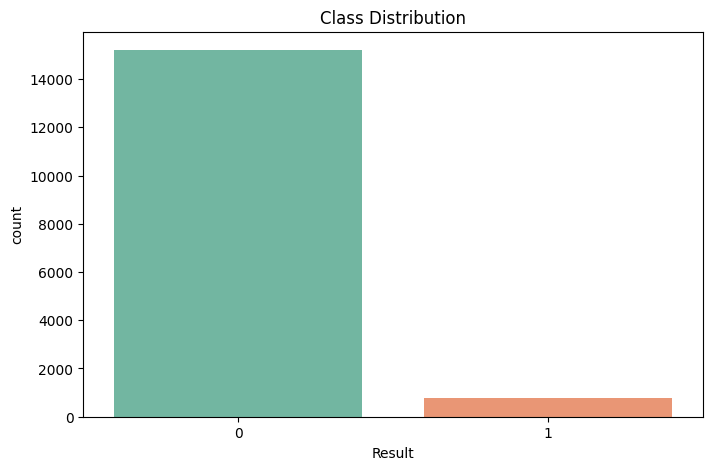

In [12]:
## 5. Cheking the imbalance of the response variable 'Result'

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Result', hue='Result', palette='Set2', legend=False)

plt.title("Class Distribution")
plt.show()

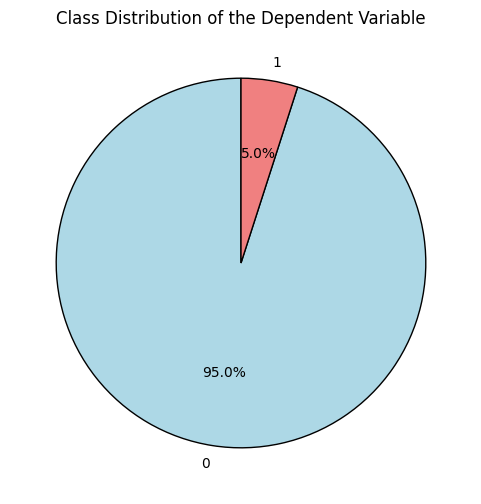


Class Counts:
Result
0    15207
1      793
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6, 6))
df['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution of the Dependent Variable")
plt.ylabel("")
plt.show()

print("\nClass Counts:")
print(df['Result'].value_counts())

<span style="font-size:20px;">The target variable 'Result' is highly imbalanced</span>

## 6. Checking for outliers using Boxplots

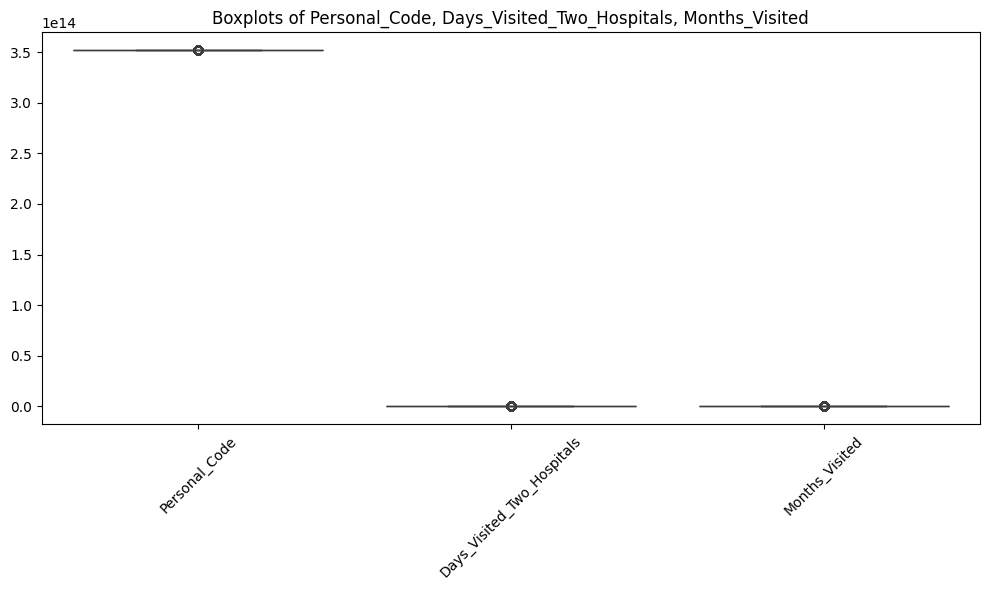

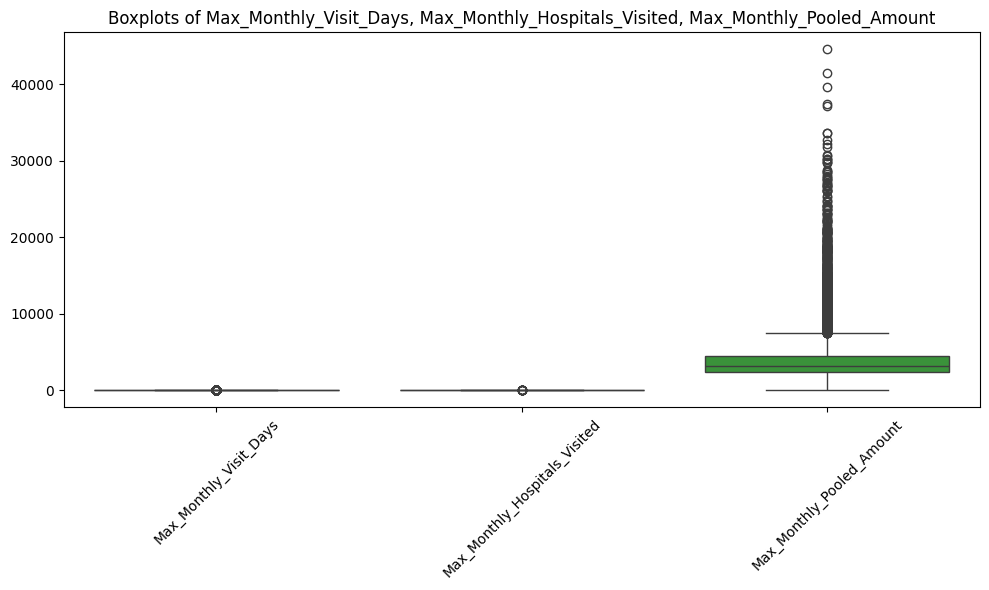

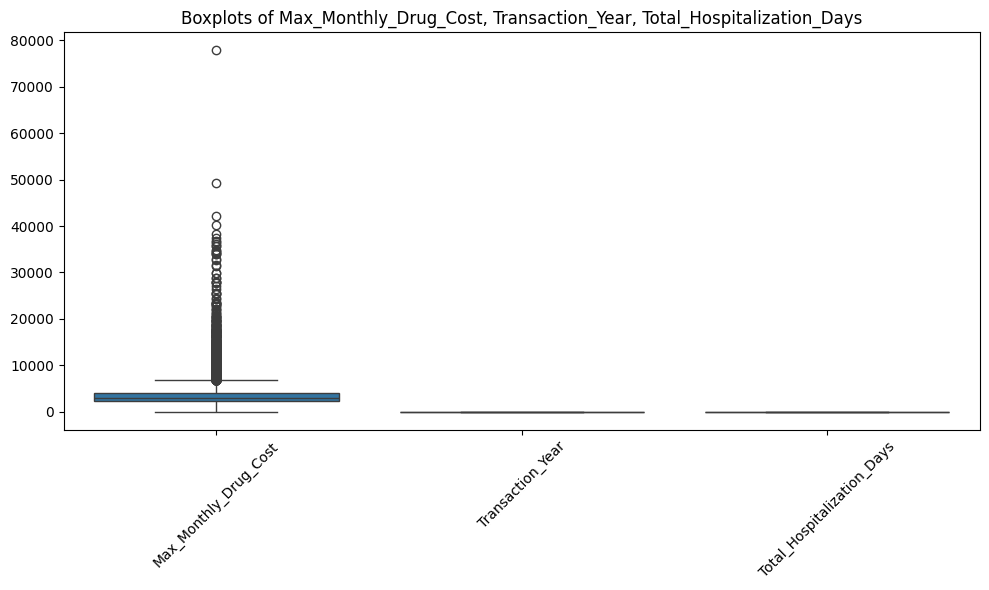

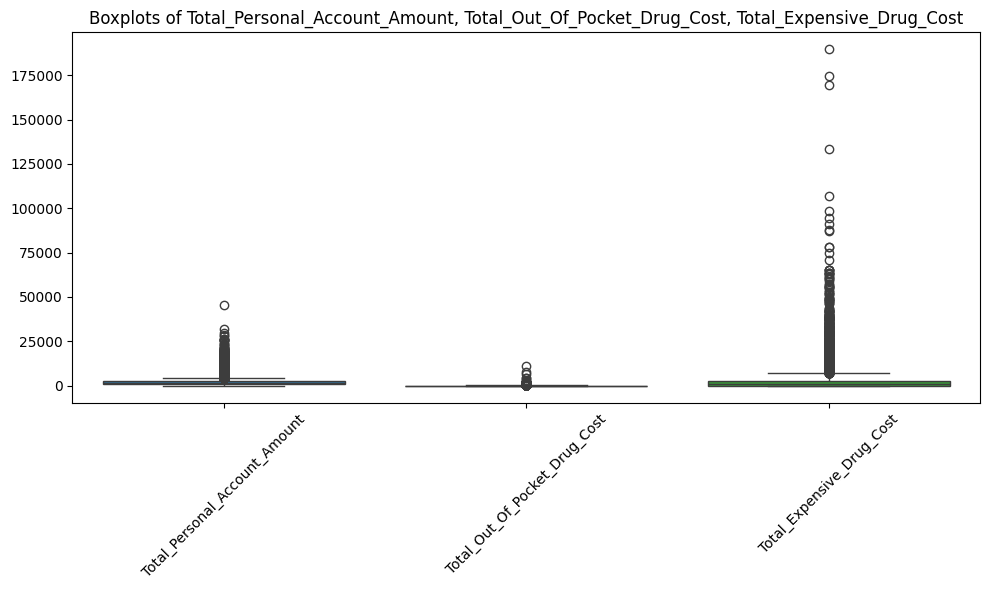

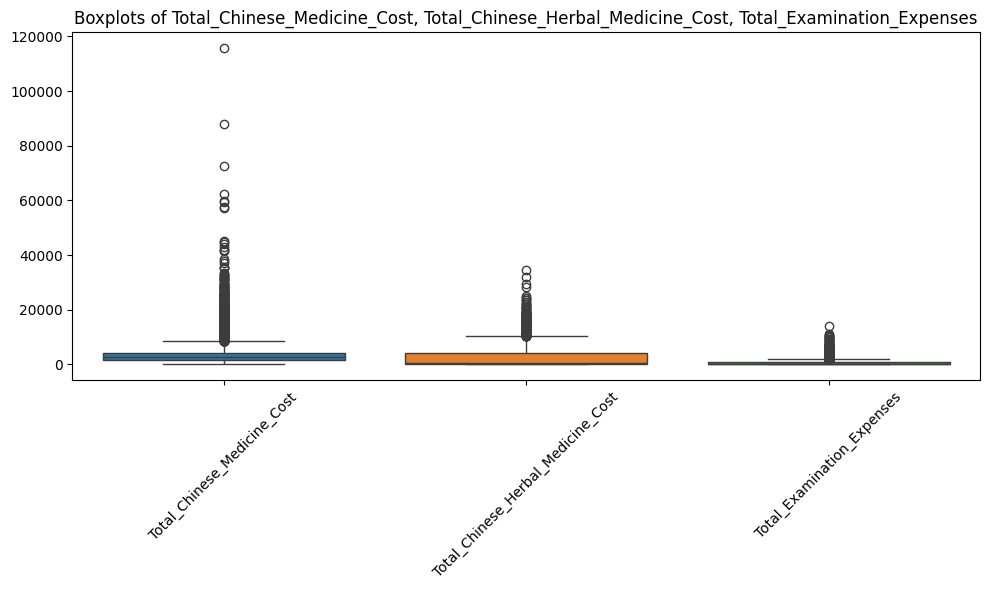

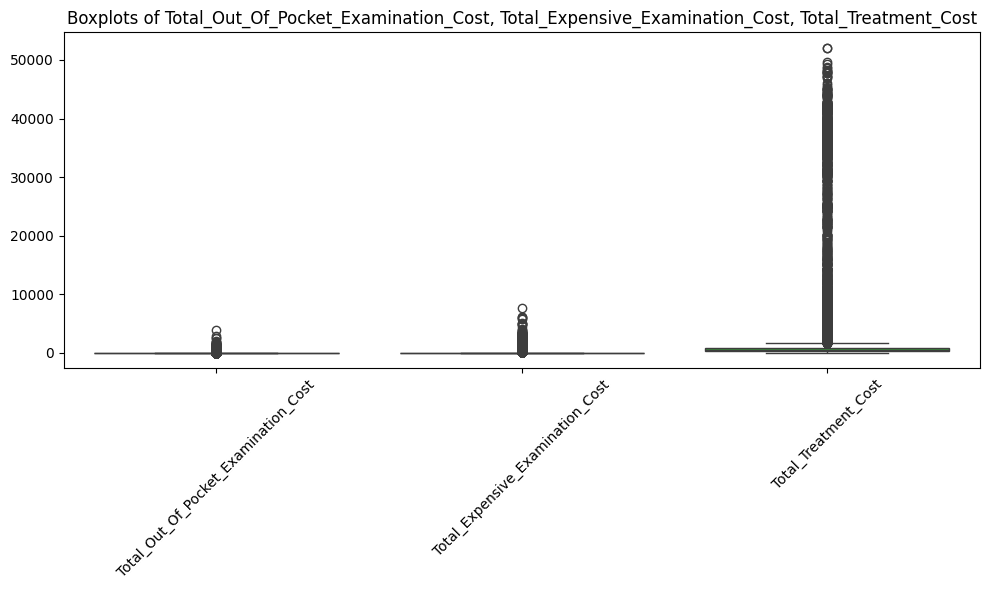

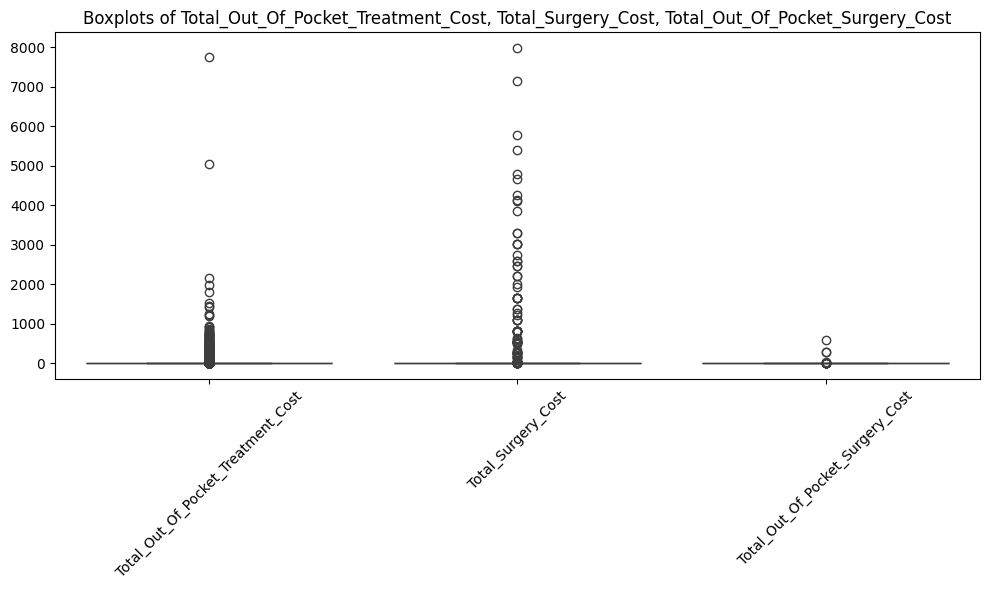

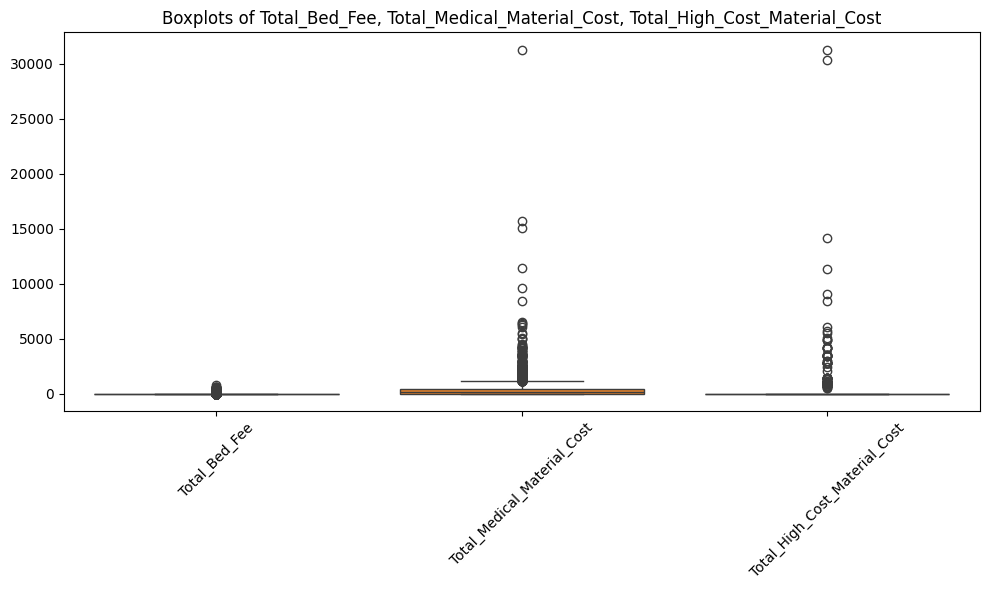

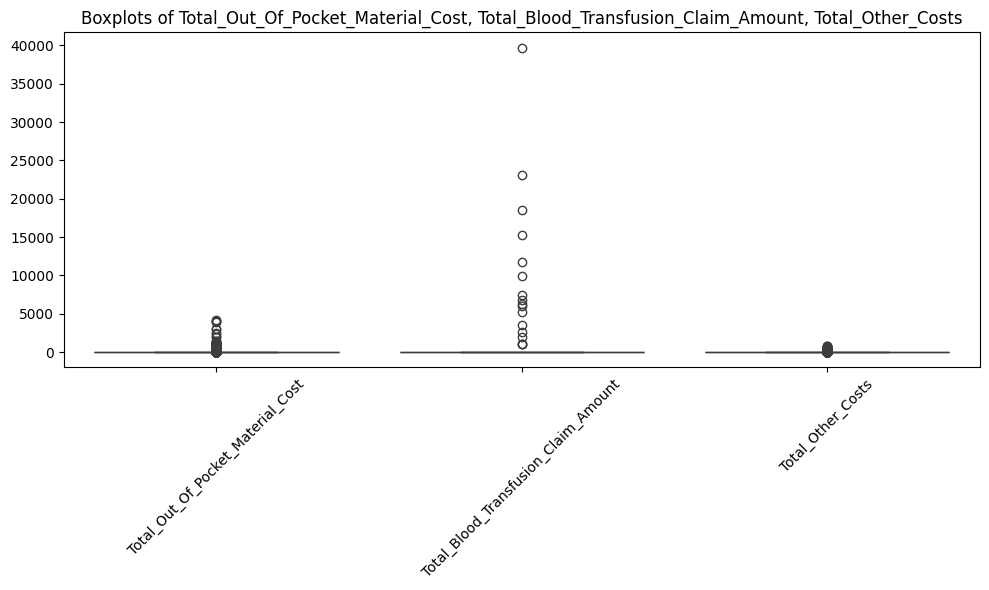

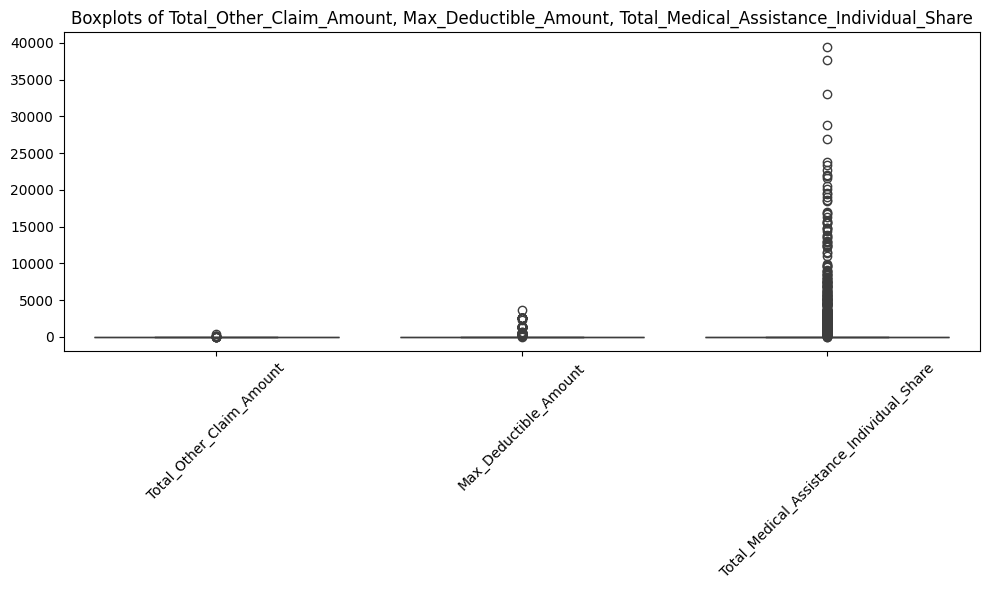

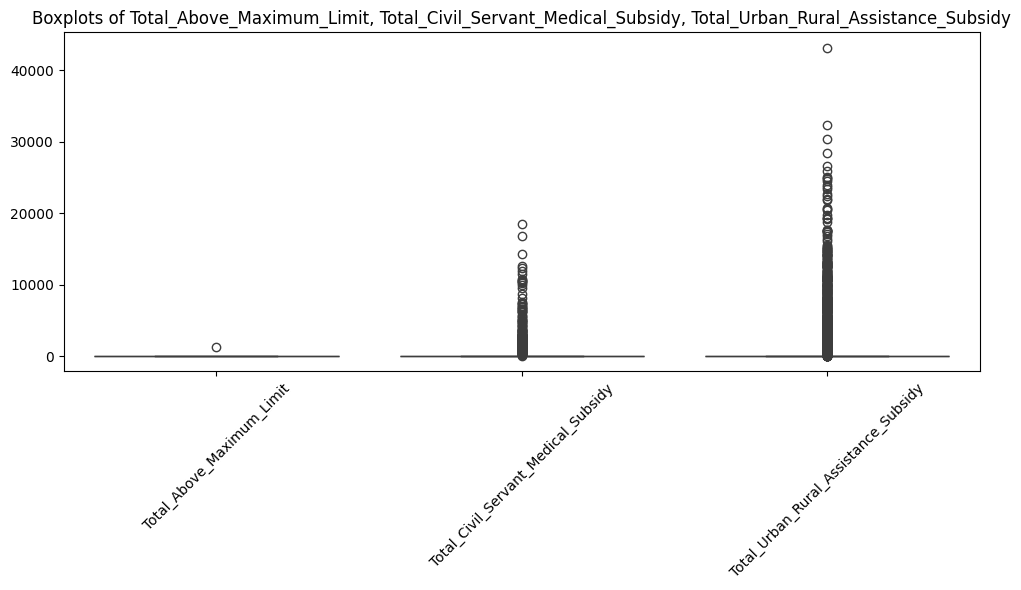

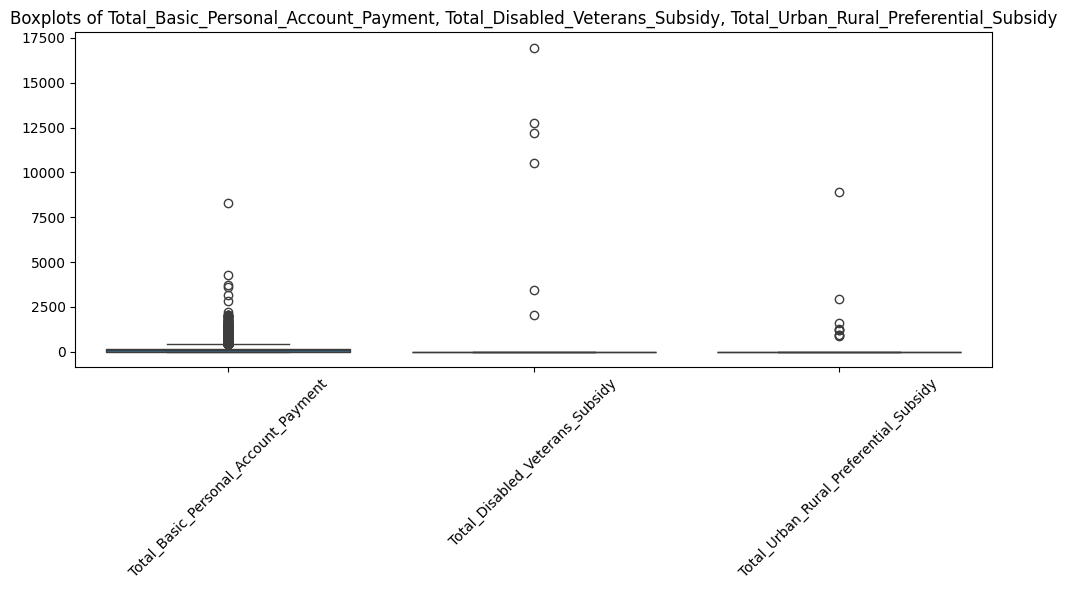

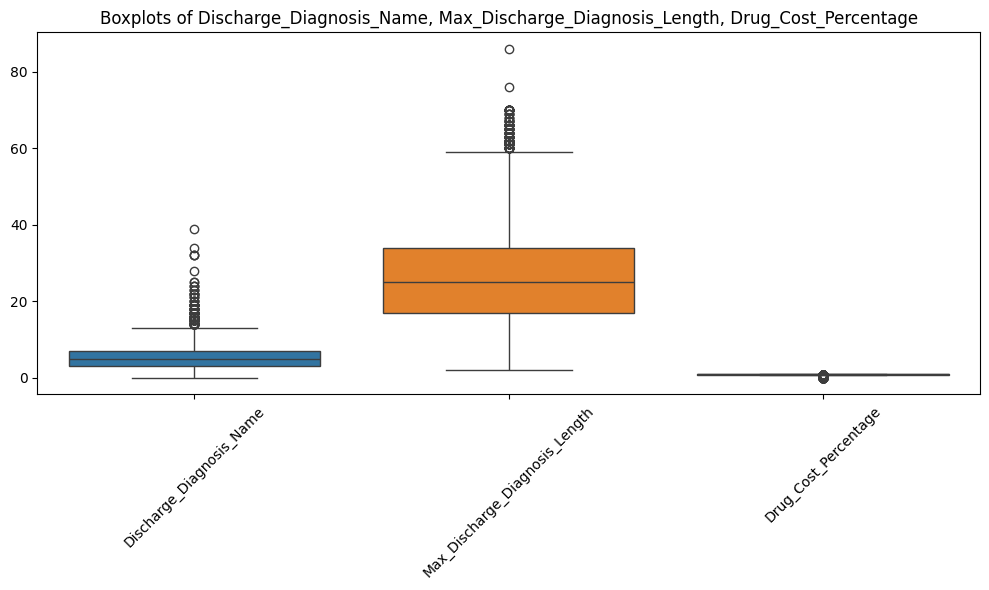

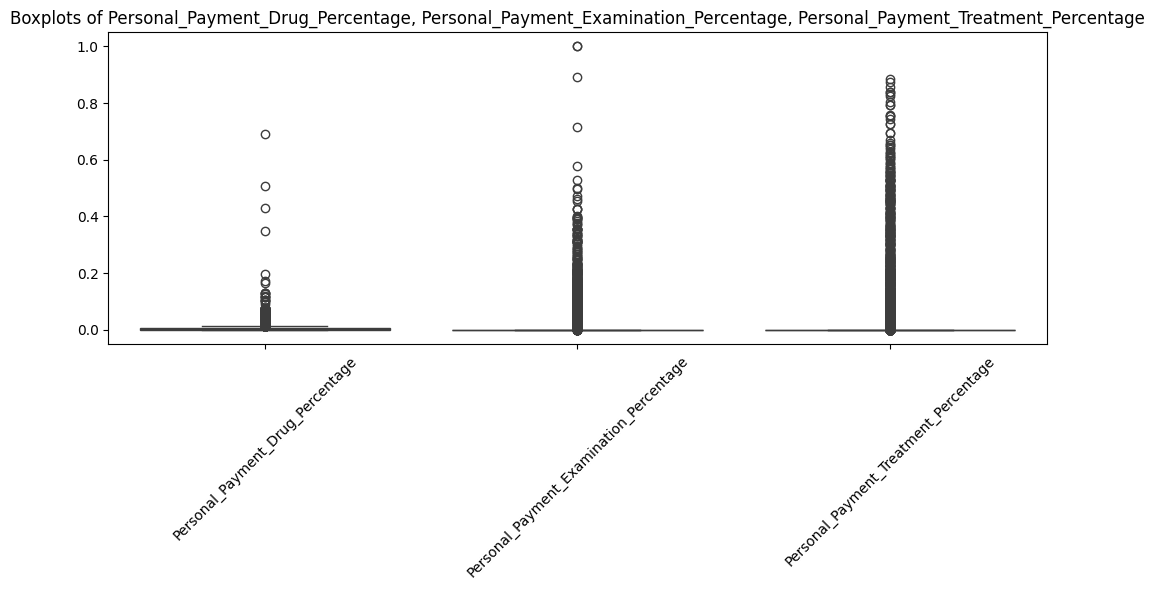

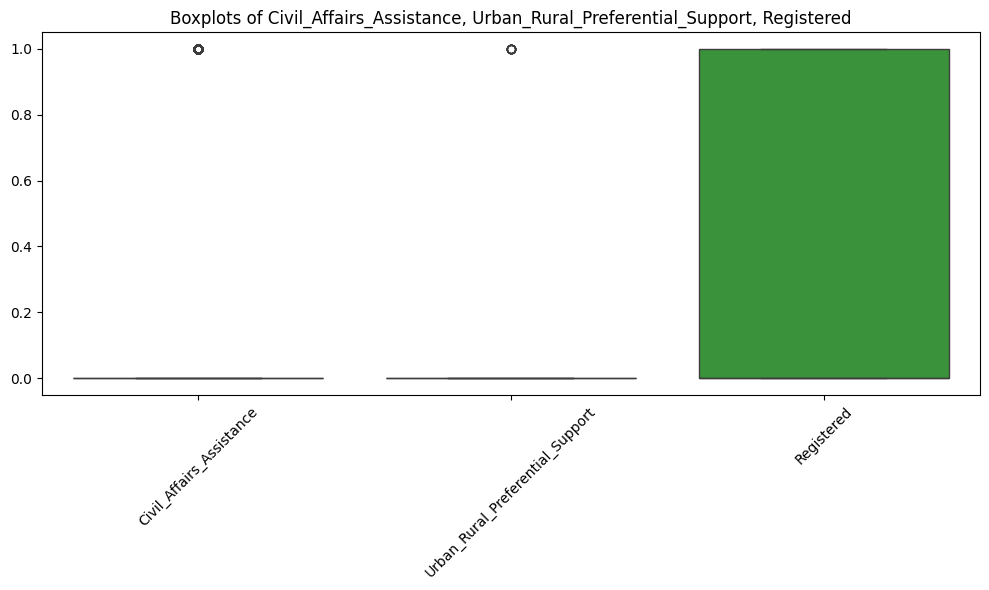

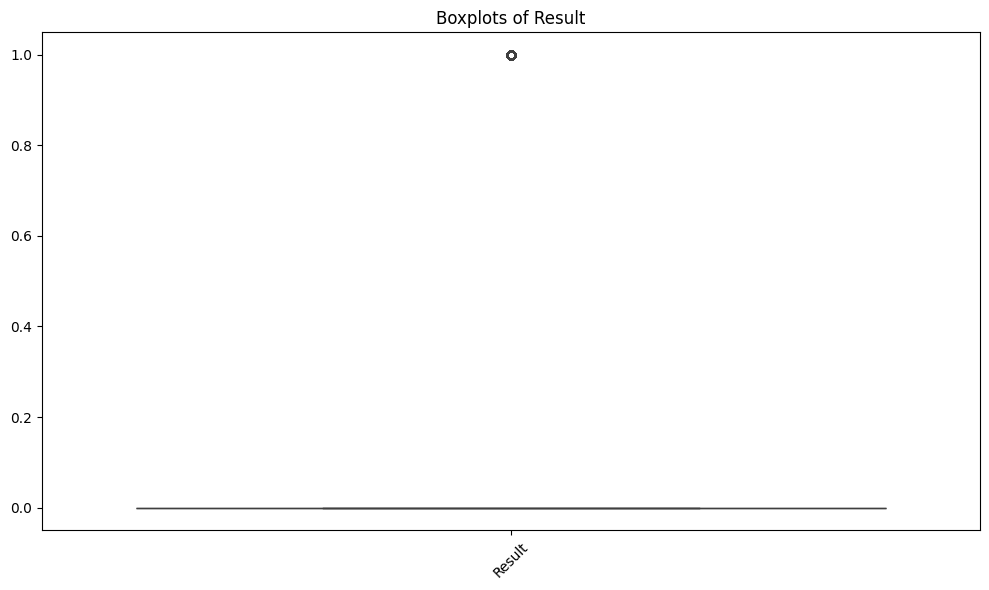

In [14]:
num_cols = df.select_dtypes(include=np.number).columns
vars_per_plot = 3

# Plot boxplots in groups
for i in range(0, len(num_cols), vars_per_plot):
    cols_to_plot = num_cols[i:i + vars_per_plot]
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[cols_to_plot])
    plt.title(f'Boxplots of {", ".join(cols_to_plot)}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<span style="font-size:18px;">The is a presence of outliers in most of the variables</span>

# Model Picking - Lazy Predict

## 1. Lazy Predict

In [15]:
X, y = df.drop(columns=['Result']), df['Result']

In [16]:
feature_names = X.columns

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = StandardScaler().fit_transform(X_train), StandardScaler().fit_transform(X_test)

  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 97%|███████████████████████████████████████████████████████████████████████████████▍  | 31/32 [02:32<00:02,  2.45s/it]

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5688
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [02:35<00:00,  4.85s/it]


                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.90               0.73     0.73      0.92   
DecisionTreeClassifier             0.94               0.73     0.73      0.94   
LinearDiscriminantAnalysis         0.96               0.71     0.71      0.95   
BaggingClassifier                  0.96               0.70     0.70      0.96   
Perceptron                         0.91               0.69     0.69      0.92   
XGBClassifier                      0.96               0.68     0.68      0.96   
LGBMClassifier                     0.96               0.68     0.68      0.96   
BernoulliNB                        0.57               0.67     0.67      0.69   
RandomForestClassifier             0.97               0.67     0.67      0.96   
SGDClassifier                      0.95               0.66     0.66      0.95   
ExtraTreeClassifier         

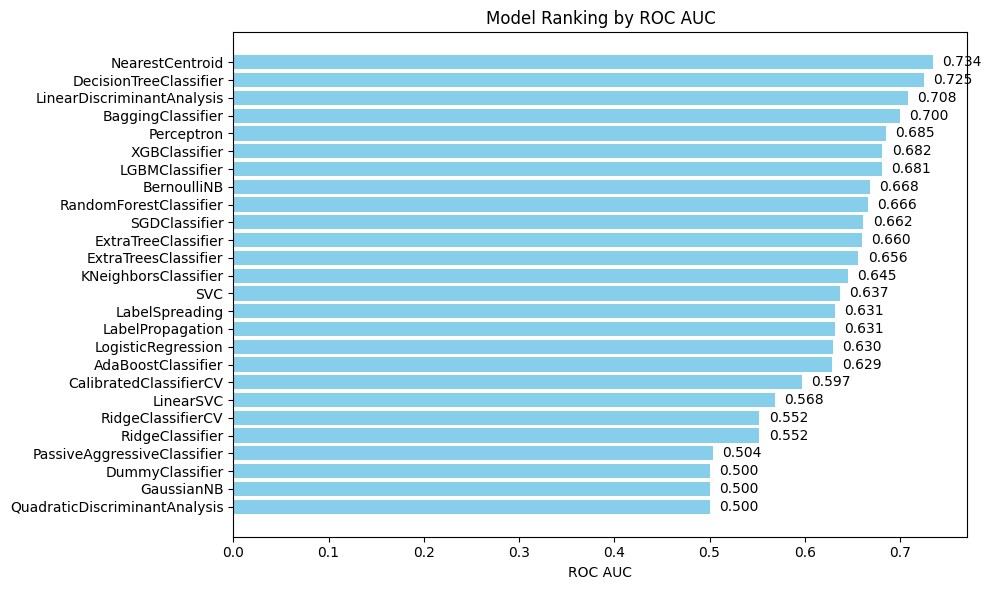

In [18]:
models, _ = LazyClassifier(verbose=0, ignore_warnings=True).fit(X_train, X_test, y_train, y_test)
print(models)

plt.figure(figsize=(10, 6))
models_sorted = models.sort_values(by="ROC AUC", ascending=False)

bars = plt.barh(models_sorted.index, models_sorted["ROC AUC"], color="skyblue")

for bar, value in zip(bars, models_sorted["ROC AUC"]):
    plt.text(
        bar.get_width() + 0.01,        
        bar.get_y() + bar.get_height()/2, 
        f"{value:.3f}", 
        va="center"
    )

plt.xlabel("ROC AUC")
plt.title("Model Ranking by ROC AUC")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

## Models To be based on an threshold of ROC-AUC > 0.65
1. **NearestCentroid**
2. **DecisionTreeClassifier**
3. **LinearDiscriminantAnalysis**
4. **BaggingClassifier** 
5. **Perceptron**
6. **XGBClassifier**
7. **LGBMClassifier**
8. **BernoulliNB** 
9. **RandomForestClassifier**
10. **SGDClassifier**
11. **ExtraTreeClassifier**
12. **ExtraTreesClassifier**

# Modelling

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    auc,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef
)
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import ADASYN

## Recursive Feature Elimination (RFE)

In [20]:
# Applying RFE
estimator = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selector = RFECV(estimator=estimator, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
selector.fit(X_train, y_train)

print("Optimal number of features selected:", selector.n_features_)

Optimal number of features selected: 20


In [21]:
selected_features = np.array(feature_names)[selector.support_]
print("Selected features:")
print(selected_features.tolist())

Selected features:
['Days_Visited_Two_Hospitals', 'Months_Visited', 'Max_Monthly_Visit_Days', 'Max_Monthly_Pooled_Amount', 'Max_Monthly_Drug_Cost', 'Total_Personal_Account_Amount', 'Total_Out_Of_Pocket_Drug_Cost', 'Total_Expensive_Drug_Cost', 'Total_Chinese_Medicine_Cost', 'Total_Chinese_Herbal_Medicine_Cost', 'Total_Examination_Expenses', 'Total_Treatment_Cost', 'Total_Medical_Material_Cost', 'Total_Medical_Assistance_Individual_Share', 'Total_Urban_Rural_Assistance_Subsidy', 'Total_Basic_Personal_Account_Payment', 'Discharge_Diagnosis_Name', 'Max_Discharge_Diagnosis_Length', 'Drug_Cost_Percentage', 'Personal_Payment_Drug_Percentage']


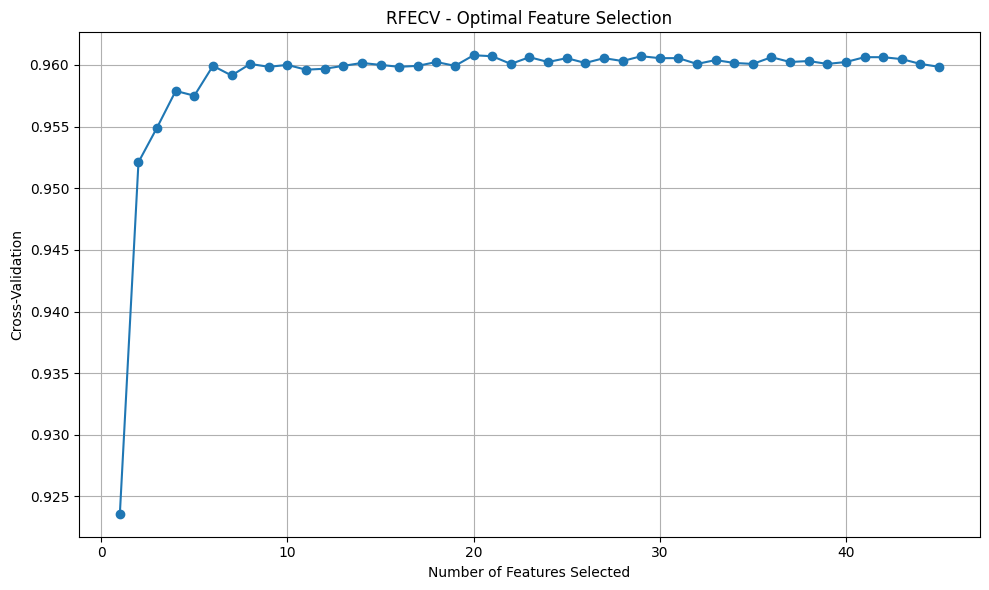

In [22]:
# Plot performance vs number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation")
plt.title("RFECV - Optimal Feature Selection")
plt.grid(True)
plt.tight_layout()
plt.show()


Feature importances:
Max_Monthly_Pooled_Amount                   0.13
Max_Monthly_Drug_Cost                       0.10
Total_Personal_Account_Amount               0.08
Max_Monthly_Visit_Days                      0.07
Total_Treatment_Cost                        0.06
Drug_Cost_Percentage                        0.06
Total_Chinese_Medicine_Cost                 0.05
Total_Out_Of_Pocket_Drug_Cost               0.05
Total_Examination_Expenses                  0.04
Personal_Payment_Drug_Percentage            0.04
Total_Medical_Material_Cost                 0.04
Max_Discharge_Diagnosis_Length              0.04
Total_Expensive_Drug_Cost                   0.04
Discharge_Diagnosis_Name                    0.04
Total_Basic_Personal_Account_Payment        0.03
Total_Chinese_Herbal_Medicine_Cost          0.03
Total_Medical_Assistance_Individual_Share   0.03
Days_Visited_Two_Hospitals                  0.03
Total_Urban_Rural_Assistance_Subsidy        0.03
Months_Visited                              0.0

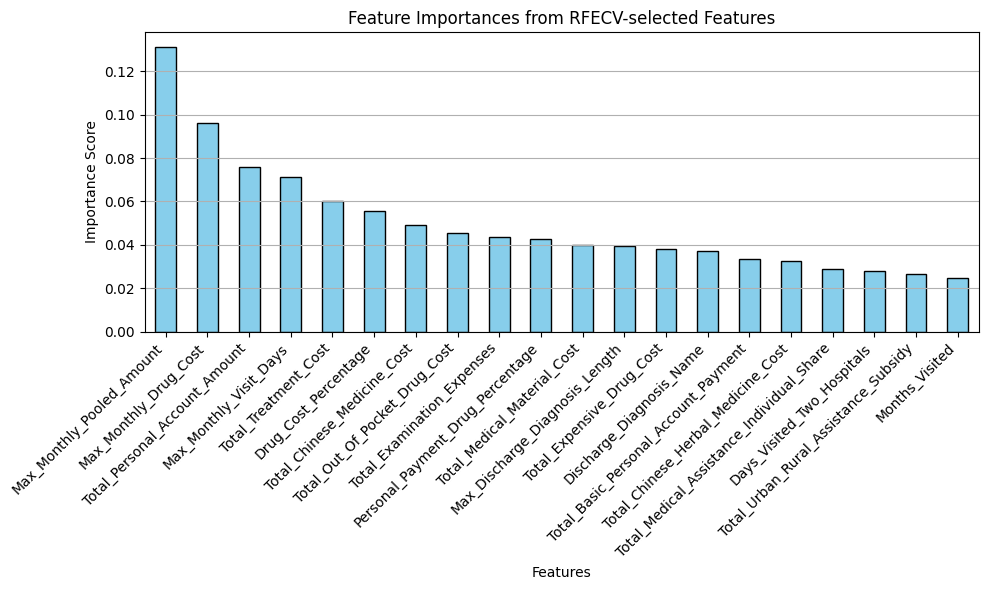

In [23]:
feature_importances = selector.estimator_.feature_importances_
important_features = pd.Series(feature_importances, index=selected_features)
important_features = important_features.sort_values(ascending=False)

print("\nFeature importances:")
print(important_features)

# Plot feature importances
plt.figure(figsize=(10, 6))
important_features.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Feature Importances from RFECV-selected Features")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [24]:
# Transform train and test sets based on selected features
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)
y_train_rfe = y_train
y_test_rfe = y_test

## 1. Nearest Centroid

In [25]:
# Initialize and train Model
nc = NearestCentroid()
nc.fit(X_train_rfe, y_train_rfe)

NearestCentroid()

In [26]:
# Make predictions
y_pred_NC = nc.predict(X_test_rfe)

In [27]:
# Evaluating the NC model
accuracy_NC = accuracy_score(y_test_rfe, y_pred_NC)
conf_matrix_NC = confusion_matrix(y_test_rfe, y_pred_NC)
class_report_NC = classification_report(y_test_rfe, y_pred_NC)

TP_NC = conf_matrix_NC[1, 1]
FN_NC = conf_matrix_NC[1, 0]
FP_NC = conf_matrix_NC[0, 1]
TN_NC = conf_matrix_NC[0, 0]

TPR_NC = TP_NC / (TP_NC + FN_NC) if (TP_NC + FN_NC) > 0 else 0
FPR_NC = FP_NC / (FP_NC + TN_NC) if (FP_NC + TN_NC) > 0 else 0
balanced_accuracy_NC = (TPR_NC + (TN_NC / (TN_NC + FP_NC))) / 2 if (TN_NC + FP_NC) > 0 else 0

print("Evaluation Metrics for NC:")
print(f'Accuracy: {accuracy_NC:.4f}')
print(f'True Positive Rate (TPR): {TPR_NC:.4f}')
print(f'False Positive Rate (FPR): {FPR_NC:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_NC:.4f}')
print('\nClassification Report:')
print(class_report_NC)

Evaluation Metrics for NC:
Accuracy: 0.9022
True Positive Rate (TPR): 0.5461
False Positive Rate (FPR): 0.0801
Balanced Accuracy: 0.7330

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3048
           1       0.25      0.55      0.35       152

    accuracy                           0.90      3200
   macro avg       0.61      0.73      0.65      3200
weighted avg       0.94      0.90      0.92      3200



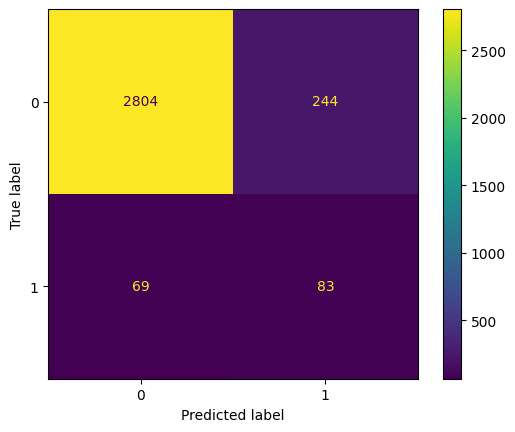

In [28]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_NC, display_labels=nc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4107188807741831
ROC-AUC: 0.7451
Matthews Correlation Coefficient (MCC): 0.3272


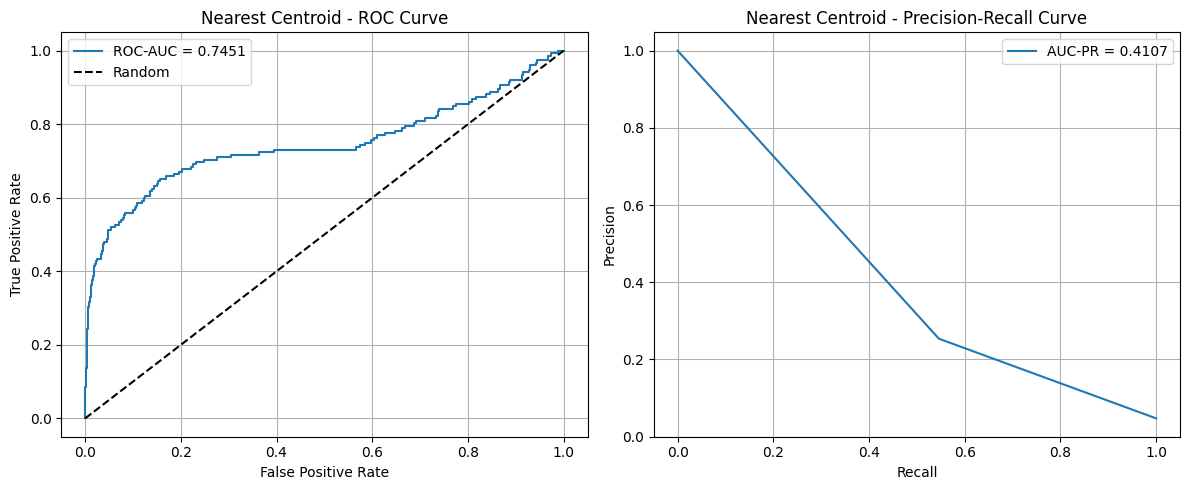

In [29]:
# AUC-OC, AUC-PR and MCC
precision_NC, recall_NC, _ = precision_recall_curve(y_test_rfe, y_pred_NC)
auc_pr_NC = auc(recall_NC, precision_NC)
print("AUC-PR:", auc_pr_NC)

try:
    decision_scores_NC = nc.decision_function(X_test_rfe)
    fpr_roc_NC, tpr_roc_NC, _ = roc_curve(y_test_rfe, decision_scores_NC)
    roc_auc_NC = auc(fpr_roc_NC, tpr_roc_NC)
    print(f"ROC-AUC: {roc_auc_NC:.4f}")
except:
    print("ROC-AUC: Not available (using predicted labels)")

mcc_NC = matthews_corrcoef(y_test_rfe, y_pred_NC)
print(f"Matthews Correlation Coefficient (MCC): {mcc_NC:.4f}")

# ROC and Precision-recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_NC, tpr_roc_NC, label=f'ROC-AUC = {roc_auc_NC:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Nearest Centroid - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_NC, precision_NC, label=f'AUC-PR = {auc_pr_NC:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Nearest Centroid - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 2. Decision Tree Classifier

In [30]:
# Initialize and train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_rfe, y_train_rfe)

DecisionTreeClassifier(random_state=42)

In [31]:
# Make predictions
y_pred_DT = dt.predict(X_test_rfe)

In [32]:
# Evaluating the DT model
accuracy_DT = accuracy_score(y_test_rfe, y_pred_DT)
conf_matrix_DT = confusion_matrix(y_test_rfe, y_pred_DT)
class_report_DT = classification_report(y_test_rfe, y_pred_DT)

TP_DT = conf_matrix_DT[1, 1]
FN_DT = conf_matrix_DT[1, 0]
FP_DT = conf_matrix_DT[0, 1]
TN_DT = conf_matrix_DT[0, 0]

TPR_DT = TP_DT / (TP_DT + FN_DT) if (TP_DT + FN_DT) > 0 else 0
FPR_DT = FP_DT / (FP_DT + TN_DT) if (FP_DT + TN_DT) > 0 else 0
balanced_accuracy_DT = (TPR_DT + (TN_DT / (TN_DT + FP_DT))) / 2 if (TN_DT + FP_DT) > 0 else 0

print("Evaluation Metrics for DT:")
print(f'Accuracy: {accuracy_DT:.4f}')
print(f'True Positive Rate (TPR): {TPR_DT:.4f}')
print(f'False Positive Rate (FPR): {FPR_DT:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_DT:.4f}')
print('\nClassification Report:')
print(class_report_DT)

Evaluation Metrics for DT:
Accuracy: 0.9359
True Positive Rate (TPR): 0.4474
False Positive Rate (FPR): 0.0397
Balanced Accuracy: 0.7038

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3048
           1       0.36      0.45      0.40       152

    accuracy                           0.94      3200
   macro avg       0.67      0.70      0.68      3200
weighted avg       0.94      0.94      0.94      3200



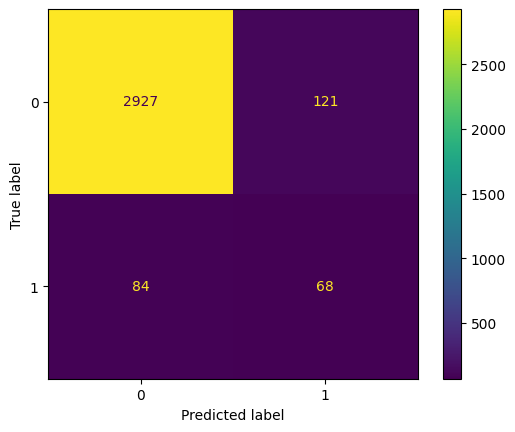

In [33]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_DT, display_labels=dt.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4167033904204957
ROC-AUC: 0.7038
Matthews Correlation Coefficient (MCC): 0.3678


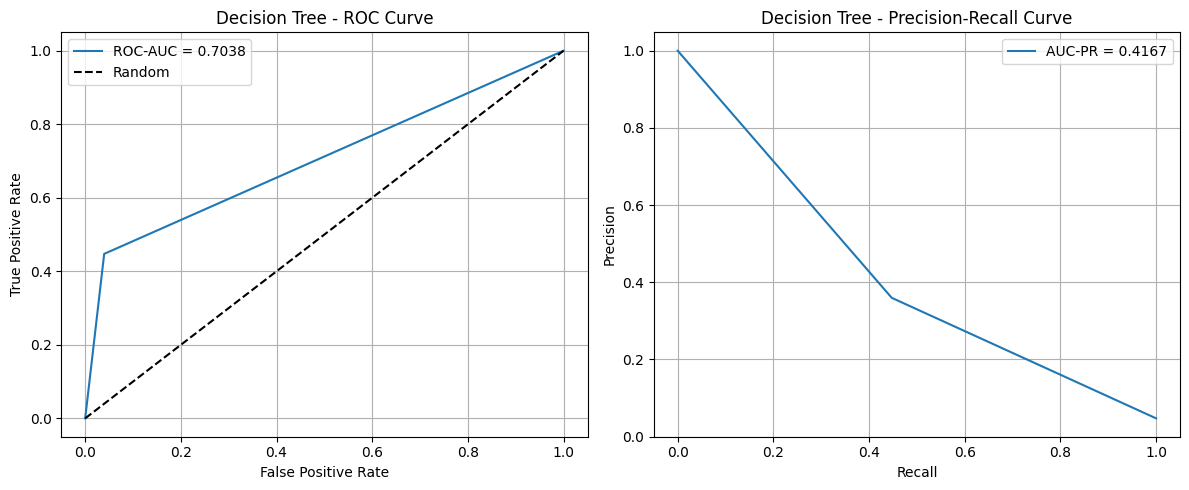

In [34]:
# ROC-AUC, AUC-PR and MCC
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_DT)
auc_pr_DT = auc(recall, precision)

y_pred_proba_DT = dt.predict_proba(X_test_rfe)[:, 1]
fpr_roc, tpr_roc, _ = roc_curve(y_test_rfe, y_pred_proba_DT)
roc_auc_DT = auc(fpr_roc, tpr_roc)

mcc_DT = matthews_corrcoef(y_test_rfe, y_pred_DT)

print("AUC-PR:", auc_pr_DT)
print(f"ROC-AUC: {roc_auc_DT:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_DT:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc, tpr_roc, label=f'ROC-AUC = {roc_auc_DT:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Decision Tree - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_DT:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Decision Tree - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 3. Linear Discriminant Analysis

In [35]:
# Initialize and train Model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_rfe, y_train_rfe)

LinearDiscriminantAnalysis()

In [36]:
# Make predictions
y_pred_LDA = lda.predict(X_test_rfe)

In [37]:
# Evaluating the LDA model
accuracy_LDA = accuracy_score(y_test_rfe, y_pred_LDA)
conf_matrix_LDA = confusion_matrix(y_test_rfe, y_pred_LDA)
class_report_LDA = classification_report(y_test_rfe, y_pred_LDA)

TP_LDA = conf_matrix_LDA[1, 1]
FN_LDA = conf_matrix_LDA[1, 0]
FP_LDA = conf_matrix_LDA[0, 1]
TN_LDA = conf_matrix_LDA[0, 0]

TPR_LDA = TP_LDA / (TP_LDA + FN_LDA) if (TP_LDA + FN_LDA) > 0 else 0
FPR_LDA = FP_LDA / (FP_LDA + TN_LDA) if (FP_LDA + TN_LDA) > 0 else 0
balanced_accuracy_LDA = (TPR_LDA + (TN_LDA / (TN_LDA + FP_LDA))) / 2 if (TN_LDA + FP_LDA) > 0 else 0

print("Evaluation Metrics for LDA:")
print(f'Accuracy: {accuracy_LDA:.4f}')
print(f'True Positive Rate (TPR): {TPR_LDA:.4f}')
print(f'False Positive Rate (FPR): {FPR_LDA:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_LDA:.4f}')
print('\nClassification Report:')
print(class_report_LDA)

Evaluation Metrics for LDA:
Accuracy: 0.9575
True Positive Rate (TPR): 0.4145
False Positive Rate (FPR): 0.0154
Balanced Accuracy: 0.6995

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3048
           1       0.57      0.41      0.48       152

    accuracy                           0.96      3200
   macro avg       0.77      0.70      0.73      3200
weighted avg       0.95      0.96      0.95      3200



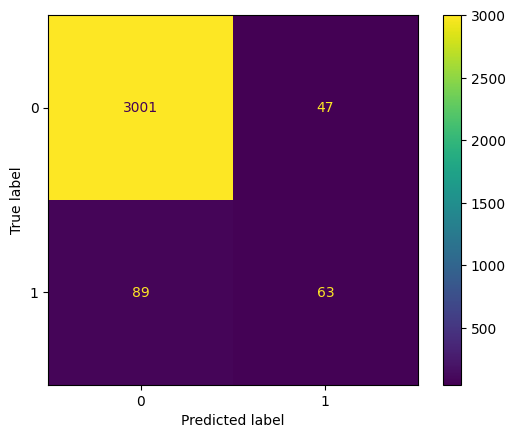

In [38]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LDA, display_labels=lda.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5075067284688995
ROC-AUC: 0.7954
Matthews Correlation Coefficient (MCC): 0.4659


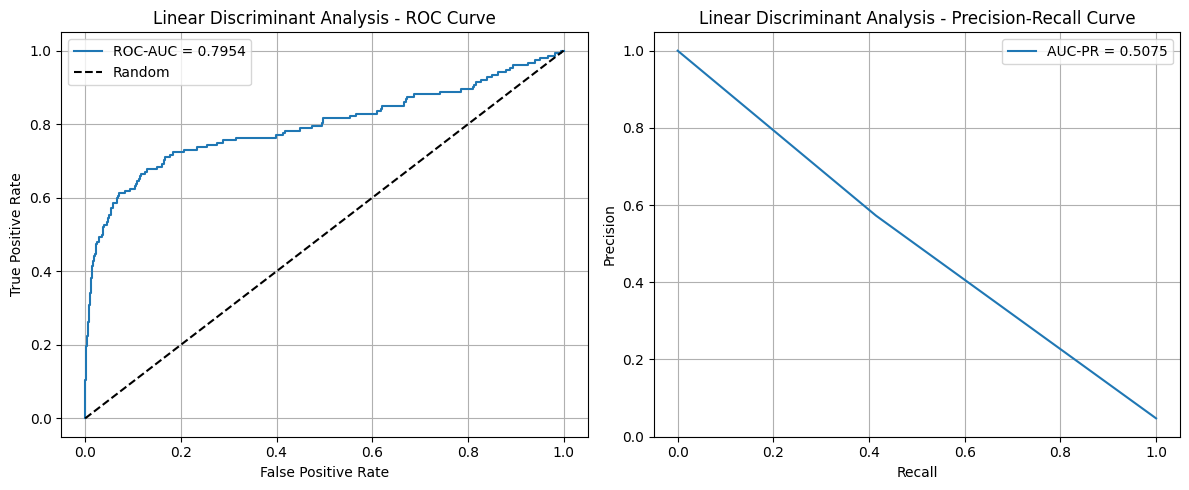

In [39]:
# ROC-AUC, AUC-PR and MCC
precision_LDA, recall_LDA, _ = precision_recall_curve(y_test_rfe, y_pred_LDA)
auc_pr_LDA = auc(recall_LDA, precision_LDA)

y_pred_proba_LDA = lda.predict_proba(X_test_rfe)[:, 1]
fpr_roc_LDA, tpr_roc_LDA, _ = roc_curve(y_test_rfe, y_pred_proba_LDA)
roc_auc_LDA = auc(fpr_roc_LDA, tpr_roc_LDA)

mcc_LDA = matthews_corrcoef(y_test_rfe, y_pred_LDA)

print("AUC-PR:", auc_pr_LDA)
print(f"ROC-AUC: {roc_auc_LDA:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_LDA:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_LDA, tpr_roc_LDA, label=f'ROC-AUC = {roc_auc_LDA:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Linear Discriminant Analysis - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_LDA, precision_LDA, label=f'AUC-PR = {auc_pr_LDA:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Linear Discriminant Analysis - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 4. Bagging Classifier

In [40]:
# Initialize and train Model
bagging = BaggingClassifier(random_state=42)
bagging.fit(X_train_rfe, y_train_rfe)

BaggingClassifier(random_state=42)

In [41]:
# Make predictions
y_pred_BAG = bagging.predict(X_test_rfe)

In [42]:
# Evaluating the BAG model
accuracy_BAG = accuracy_score(y_test_rfe, y_pred_BAG)
conf_matrix_BAG = confusion_matrix(y_test_rfe, y_pred_BAG)
class_report_BAG = classification_report(y_test_rfe, y_pred_BAG)

TP_BAG = conf_matrix_BAG[1, 1]
FN_BAG = conf_matrix_BAG[1, 0]
FP_BAG = conf_matrix_BAG[0, 1]
TN_BAG = conf_matrix_BAG[0, 0]

TPR_BAG = TP_BAG / (TP_BAG + FN_BAG) if (TP_BAG + FN_BAG) > 0 else 0
FPR_BAG = FP_BAG / (FP_BAG + TN_BAG) if (FP_BAG + TN_BAG) > 0 else 0
balanced_accuracy_BAG = (TPR_BAG + (TN_BAG / (TN_BAG + FP_BAG))) / 2 if (TN_BAG + FP_BAG) > 0 else 0

print("Evaluation Metrics for BAG:")
print(f'Accuracy: {accuracy_BAG:.4f}')
print(f'True Positive Rate (TPR): {TPR_BAG:.4f}')
print(f'False Positive Rate (FPR): {FPR_BAG:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_BAG:.4f}')
print('\nClassification Report:')
print(class_report_BAG)

Evaluation Metrics for BAG:
Accuracy: 0.9628
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0079
Balanced Accuracy: 0.6836

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.70      0.38      0.49       152

    accuracy                           0.96      3200
   macro avg       0.84      0.68      0.73      3200
weighted avg       0.96      0.96      0.96      3200



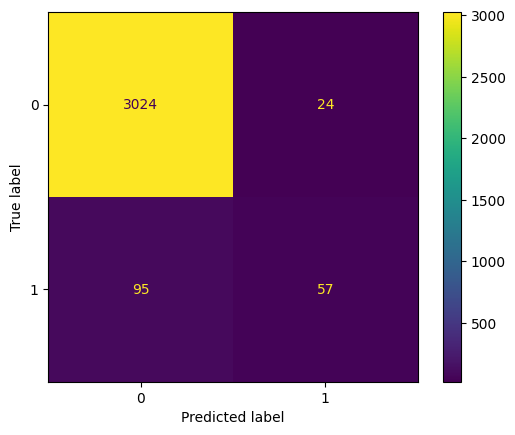

In [43]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BAG, display_labels=bagging.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5541956018518518
ROC-AUC: 0.8218
Matthews Correlation Coefficient (MCC): 0.4972


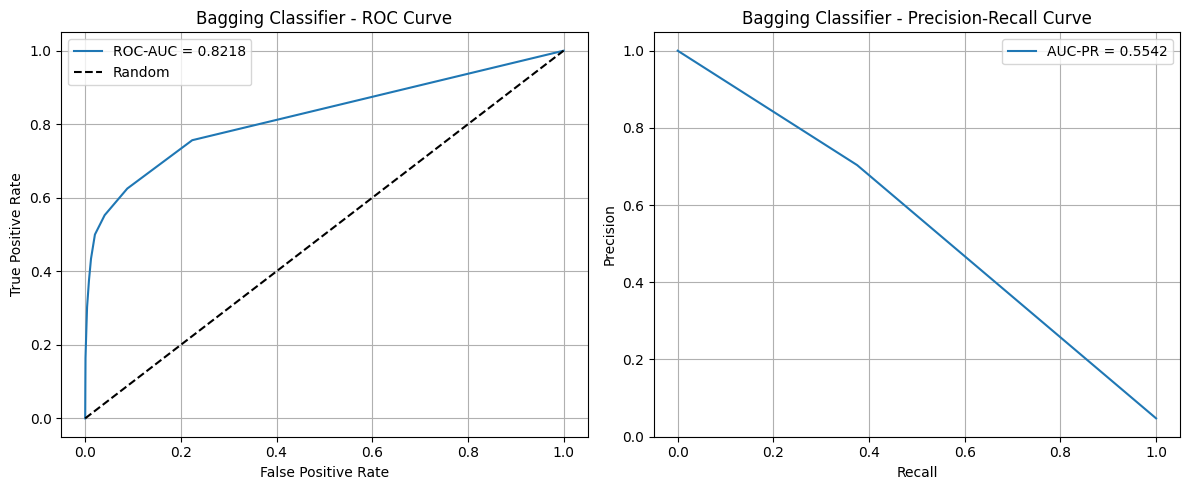

In [44]:
# ROC-AUC, AUC-PR and MCC
precision_BAG, recall_BAG, _ = precision_recall_curve(y_test_rfe, y_pred_BAG)
auc_pr_BAG = auc(recall_BAG, precision_BAG)

y_pred_proba_BAG = bagging.predict_proba(X_test_rfe)[:, 1]
fpr_roc_BAG, tpr_roc_BAG, _ = roc_curve(y_test_rfe, y_pred_proba_BAG)
roc_auc_BAG = auc(fpr_roc_BAG, tpr_roc_BAG)

mcc_BAG = matthews_corrcoef(y_test_rfe, y_pred_BAG)

print("AUC-PR:", auc_pr_BAG)
print(f"ROC-AUC: {roc_auc_BAG:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_BAG:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_BAG, tpr_roc_BAG, label=f'ROC-AUC = {roc_auc_BAG:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Bagging Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_BAG, precision_BAG, label=f'AUC-PR = {auc_pr_BAG:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Bagging Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 5. Perceptron

In [45]:
# Initialize and train Model
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train_rfe, y_train_rfe)

Perceptron(random_state=42)

In [46]:
# Make predictions
y_pred_PRC = perceptron.predict(X_test_rfe)

In [47]:
# Evaluating the PRC model
accuracy_PRC = accuracy_score(y_test_rfe, y_pred_PRC)
conf_matrix_PRC = confusion_matrix(y_test_rfe, y_pred_PRC)
class_report_PRC = classification_report(y_test_rfe, y_pred_PRC)

TP_PRC = conf_matrix_PRC[1, 1]
FN_PRC = conf_matrix_PRC[1, 0]
FP_PRC = conf_matrix_PRC[0, 1]
TN_PRC = conf_matrix_PRC[0, 0]

TPR_PRC = TP_PRC / (TP_PRC + FN_PRC) if (TP_PRC + FN_PRC) > 0 else 0
FPR_PRC = FP_PRC / (FP_PRC + TN_PRC) if (FP_PRC + TN_PRC) > 0 else 0
balanced_accuracy_PRC = (TPR_PRC + (TN_PRC / (TN_PRC + FP_PRC))) / 2 if (TN_PRC + FP_PRC) > 0 else 0

print("Evaluation Metrics for PRC:")
print(f'Accuracy: {accuracy_PRC:.4f}')
print(f'True Positive Rate (TPR): {TPR_PRC:.4f}')
print(f'False Positive Rate (FPR): {FPR_PRC:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_PRC:.4f}')
print('\nClassification Report:')
print(class_report_PRC)

Evaluation Metrics for PRC:
Accuracy: 0.9384
True Positive Rate (TPR): 0.3487
False Positive Rate (FPR): 0.0322
Balanced Accuracy: 0.6583

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3048
           1       0.35      0.35      0.35       152

    accuracy                           0.94      3200
   macro avg       0.66      0.66      0.66      3200
weighted avg       0.94      0.94      0.94      3200



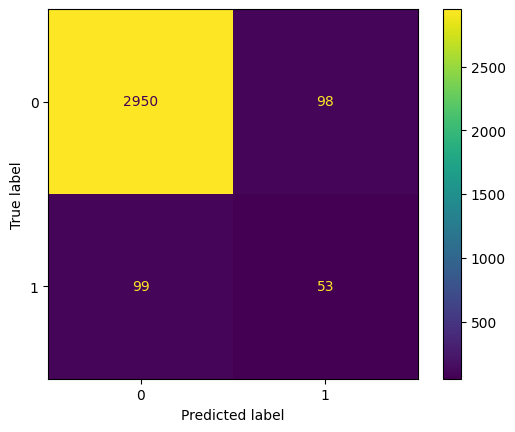

In [48]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_PRC, display_labels=perceptron.classes_)
disp.plot()
plt.show()

AUC-PR: 0.36530754400487975
ROC-AUC: 0.6597
Matthews Correlation Coefficient (MCC): 0.3175


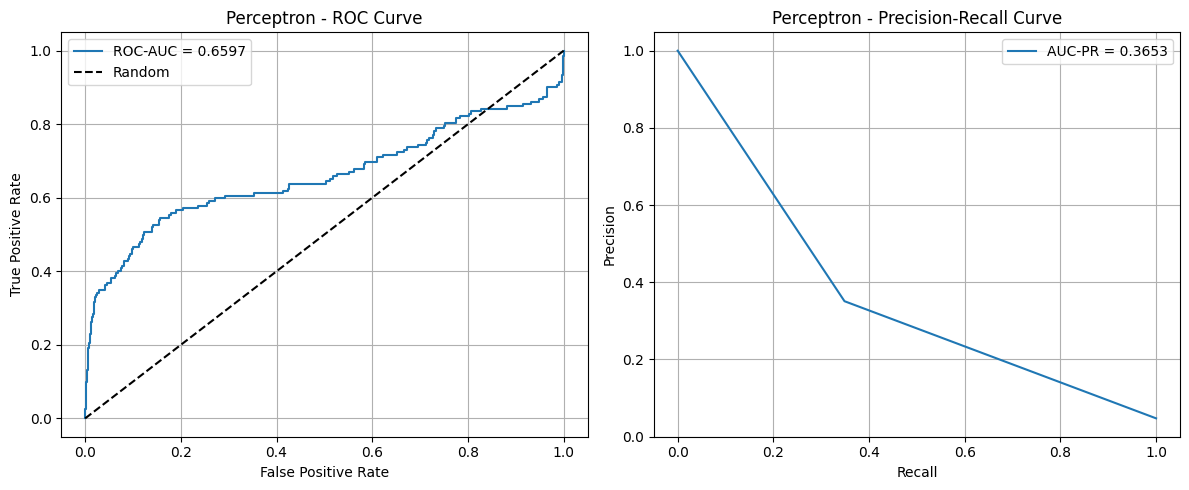

In [49]:
# ROC-AUC, AUC-PR and MCC
precision_PRC, recall_PRC, _ = precision_recall_curve(y_test_rfe, y_pred_PRC)
auc_pr_PRC = auc(recall_PRC, precision_PRC)
print("AUC-PR:", auc_pr_PRC)

try:
    decision_scores_PRC = perceptron.decision_function(X_test_rfe)
    fpr_roc_PRC, tpr_roc_PRC, _ = roc_curve(y_test_rfe, decision_scores_PRC)
    roc_auc_PRC = auc(fpr_roc_PRC, tpr_roc_PRC)
    print(f"ROC-AUC: {roc_auc_PRC:.4f}")
except:
    print("ROC-AUC: Not available (using predicted labels)")

mcc_PRC = matthews_corrcoef(y_test_rfe, y_pred_PRC)
print(f"Matthews Correlation Coefficient (MCC): {mcc_PRC:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_PRC, tpr_roc_PRC, label=f'ROC-AUC = {roc_auc_PRC:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Perceptron - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_PRC, precision_PRC, label=f'AUC-PR = {auc_pr_PRC:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Perceptron - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 6. XGB Classfier

In [50]:
# Initialize and train Model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_rfe, y_train_rfe)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [51]:
# Make predictions
y_pred_XGB = xgb.predict(X_test_rfe)

In [52]:
# Evaluating the XGB model
accuracy_XGB = accuracy_score(y_test_rfe, y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test_rfe, y_pred_XGB)
class_report_XGB = classification_report(y_test_rfe, y_pred_XGB)

TP_XGB = conf_matrix_XGB[1, 1]
FN_XGB = conf_matrix_XGB[1, 0]
FP_XGB = conf_matrix_XGB[0, 1]
TN_XGB = conf_matrix_XGB[0, 0]

TPR_XGB = TP_XGB / (TP_XGB + FN_XGB) if (TP_XGB + FN_XGB) > 0 else 0
FPR_XGB = FP_XGB / (FP_XGB + TN_XGB) if (FP_XGB + TN_XGB) > 0 else 0
balanced_accuracy_XGB = (TPR_XGB + (TN_XGB / (TN_XGB + FP_XGB))) / 2 if (TN_XGB + FP_XGB) > 0 else 0

print("Evaluation Metrics for XGB:")
print(f'Accuracy: {accuracy_XGB:.4f}')
print(f'True Positive Rate (TPR): {TPR_XGB:.4f}')
print(f'False Positive Rate (FPR): {FPR_XGB:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_XGB:.4f}')
print('\nClassification Report:')
print(class_report_XGB)

Evaluation Metrics for XGB:
Accuracy: 0.9659
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0056
Balanced Accuracy: 0.6946

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.78      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.87      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



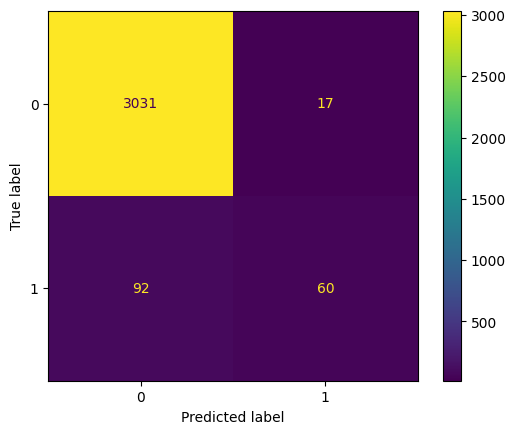

In [53]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_XGB, display_labels=xgb.classes_)
disp.plot()
plt.show()

AUC-PR XGB: 0.6013538106630212
ROC-AUC XGB: 0.8849
Matthews Correlation Coefficient (MCC) XGB: 0.5402


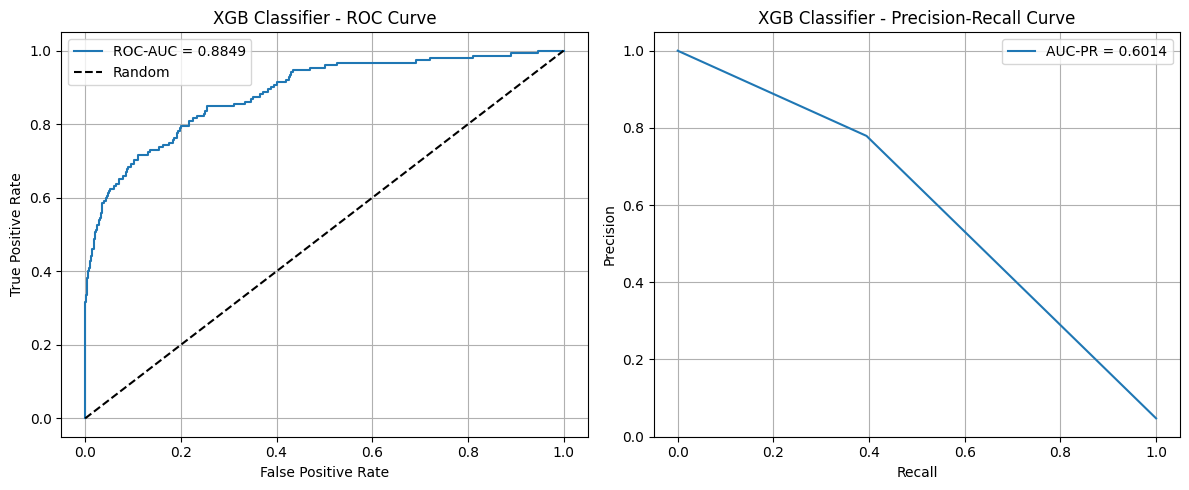

In [54]:
# ROC-AUC, AUC-PR and MCC for XGB
precision_XGB, recall_XGB, _ = precision_recall_curve(y_test_rfe, y_pred_XGB)
auc_pr_XGB = auc(recall_XGB, precision_XGB)

y_pred_proba_XGB = xgb.predict_proba(X_test_rfe)[:, 1]
fpr_roc_XGB, tpr_roc_XGB, _ = roc_curve(y_test_rfe, y_pred_proba_XGB)
roc_auc_XGB = auc(fpr_roc_XGB, tpr_roc_XGB)

mcc_XGB = matthews_corrcoef(y_test_rfe, y_pred_XGB)

print("AUC-PR XGB:", auc_pr_XGB)
print(f"ROC-AUC XGB: {roc_auc_XGB:.4f}")
print(f"Matthews Correlation Coefficient (MCC) XGB: {mcc_XGB:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_XGB, tpr_roc_XGB, label=f'ROC-AUC = {roc_auc_XGB:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('XGB Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_XGB, precision_XGB, label=f'AUC-PR = {auc_pr_XGB:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('XGB Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 7. LGBM Classifier

In [55]:
# Initialize and train Model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


LGBMClassifier(random_state=42)

In [56]:
# Make predictions
y_pred_LGBM = lgbm.predict(X_test_rfe)

In [57]:
# Evaluating the LGBM model
accuracy_LGBM = accuracy_score(y_test_rfe, y_pred_LGBM)
conf_matrix_LGBM = confusion_matrix(y_test_rfe, y_pred_LGBM)
class_report_LGBM = classification_report(y_test_rfe, y_pred_LGBM)

TP_LGBM = conf_matrix_LGBM[1, 1]
FN_LGBM = conf_matrix_LGBM[1, 0]
FP_LGBM = conf_matrix_LGBM[0, 1]
TN_LGBM = conf_matrix_LGBM[0, 0]

TPR_LGBM = TP_LGBM / (TP_LGBM + FN_LGBM) if (TP_LGBM + FN_LGBM) > 0 else 0
FPR_LGBM = FP_LGBM / (FP_LGBM + TN_LGBM) if (FP_LGBM + TN_LGBM) > 0 else 0
balanced_accuracy_LGBM = (TPR_LGBM + (TN_LGBM / (TN_LGBM + FP_LGBM))) / 2 if (TN_LGBM + FP_LGBM) > 0 else 0

print("Evaluation Metrics for LGBM:")
print(f'Accuracy: {accuracy_LGBM:.4f}')
print(f'True Positive Rate (TPR): {TPR_LGBM:.4f}')
print(f'False Positive Rate (FPR): {FPR_LGBM:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_LGBM:.4f}')
print('\nClassification Report:')
print(class_report_LGBM)

Evaluation Metrics for LGBM:
Accuracy: 0.9628
True Positive Rate (TPR): 0.3618
False Positive Rate (FPR): 0.0072
Balanced Accuracy: 0.6773

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.71      0.36      0.48       152

    accuracy                           0.96      3200
   macro avg       0.84      0.68      0.73      3200
weighted avg       0.96      0.96      0.96      3200



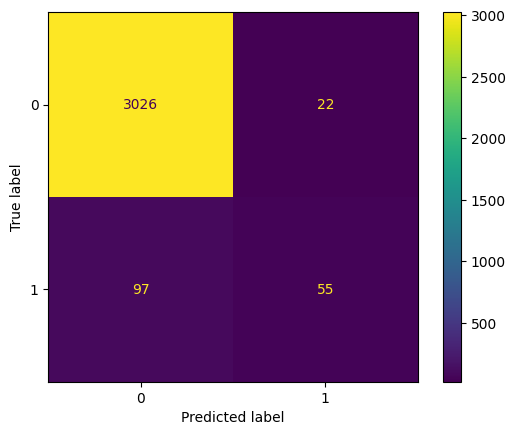

In [58]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LGBM, display_labels=lgbm.classes_)
disp.plot()
plt.show()

AUC-PR LGBM: 0.5532201597744362
ROC-AUC LGBM: 0.8996
Matthews Correlation Coefficient (MCC) LGBM: 0.4922


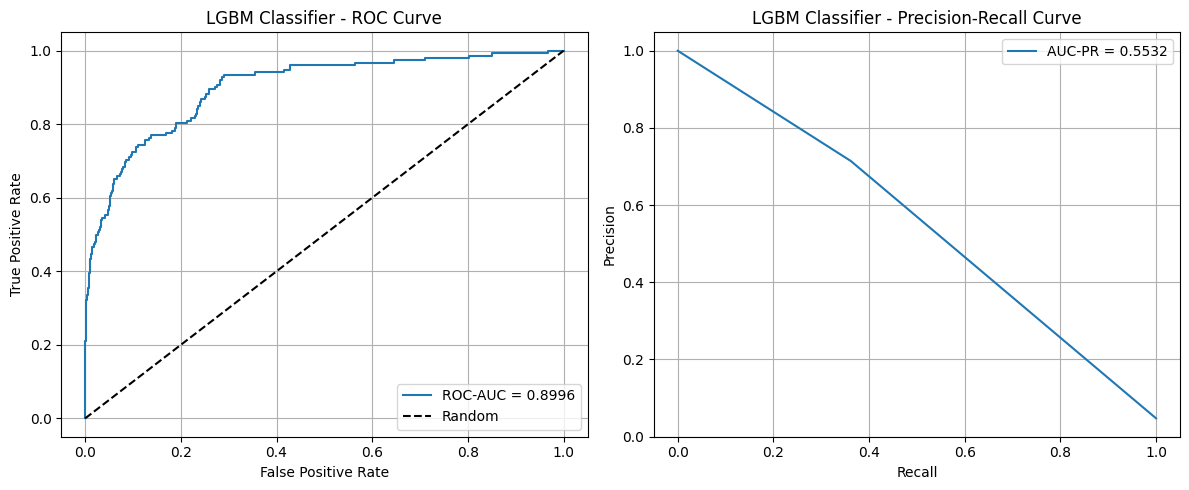

In [59]:
# ROC-AUC, AUC-PR and MCC for LGBM
precision_LGBM, recall_LGBM, _ = precision_recall_curve(y_test_rfe, y_pred_LGBM)
auc_pr_LGBM = auc(recall_LGBM, precision_LGBM)

y_pred_proba_LGBM = lgbm.predict_proba(X_test_rfe)[:, 1]
fpr_roc_LGBM, tpr_roc_LGBM, _ = roc_curve(y_test_rfe, y_pred_proba_LGBM)
roc_auc_LGBM = auc(fpr_roc_LGBM, tpr_roc_LGBM)

mcc_LGBM = matthews_corrcoef(y_test_rfe, y_pred_LGBM)

print("AUC-PR LGBM:", auc_pr_LGBM)
print(f"ROC-AUC LGBM: {roc_auc_LGBM:.4f}")
print(f"Matthews Correlation Coefficient (MCC) LGBM: {mcc_LGBM:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_LGBM, tpr_roc_LGBM, label=f'ROC-AUC = {roc_auc_LGBM:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('LGBM Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_LGBM, precision_LGBM, label=f'AUC-PR = {auc_pr_LGBM:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('LGBM Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 8. BernoulliNB Classifier

In [60]:
# Initialize and train Model
bnb = BernoulliNB()
bnb.fit(X_train_rfe, y_train_rfe)

BernoulliNB()

In [61]:
# Make predictions
y_pred_BNB = bnb.predict(X_test_rfe)

In [62]:
# Evaluating the BNB model
accuracy_BNB = accuracy_score(y_test_rfe, y_pred_BNB)
conf_matrix_BNB = confusion_matrix(y_test_rfe, y_pred_BNB)
class_report_BNB = classification_report(y_test_rfe, y_pred_BNB)

TP_BNB = conf_matrix_BNB[1, 1]
FN_BNB = conf_matrix_BNB[1, 0]
FP_BNB = conf_matrix_BNB[0, 1]
TN_BNB = conf_matrix_BNB[0, 0]

TPR_BNB = TP_BNB / (TP_BNB + FN_BNB) if (TP_BNB + FN_BNB) > 0 else 0
FPR_BNB = FP_BNB / (FP_BNB + TN_BNB) if (FP_BNB + TN_BNB) > 0 else 0
balanced_accuracy_BNB = (TPR_BNB + (TN_BNB / (TN_BNB + FP_BNB))) / 2 if (TN_BNB + FP_BNB) > 0 else 0

print("Evaluation Metrics for BNB:")
print(f'Accuracy: {accuracy_BNB:.4f}')
print(f'True Positive Rate (TPR): {TPR_BNB:.4f}')
print(f'False Positive Rate (FPR): {FPR_BNB:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_BNB:.4f}')
print('\nClassification Report:')
print(class_report_BNB)

Evaluation Metrics for BNB:
Accuracy: 0.9038
True Positive Rate (TPR): 0.5000
False Positive Rate (FPR): 0.0761
Balanced Accuracy: 0.7119

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      3048
           1       0.25      0.50      0.33       152

    accuracy                           0.90      3200
   macro avg       0.61      0.71      0.64      3200
weighted avg       0.94      0.90      0.92      3200



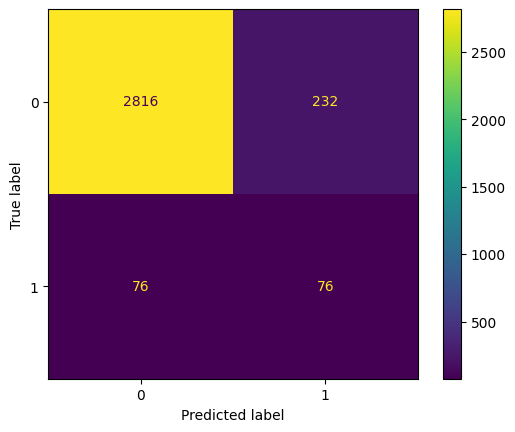

In [63]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BNB, display_labels=bnb.classes_)
disp.plot()
plt.show()

AUC-PR BNB: 0.3852516233766234
ROC-AUC BNB: 0.7678
Matthews Correlation Coefficient (MCC) BNB: 0.3057


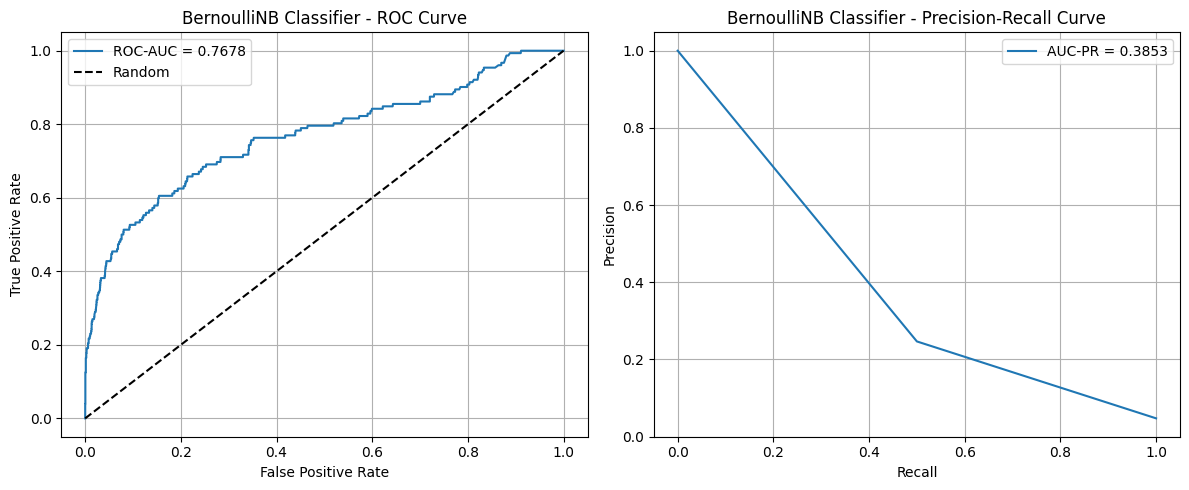

In [64]:
# ROC-AUC, AUC-PR and MCC for BNB
precision_BNB, recall_BNB, _ = precision_recall_curve(y_test_rfe, y_pred_BNB)
auc_pr_BNB = auc(recall_BNB, precision_BNB)

y_pred_proba_BNB = bnb.predict_proba(X_test_rfe)[:, 1]
fpr_roc_BNB, tpr_roc_BNB, _ = roc_curve(y_test_rfe, y_pred_proba_BNB)
roc_auc_BNB = auc(fpr_roc_BNB, tpr_roc_BNB)

mcc_BNB = matthews_corrcoef(y_test_rfe, y_pred_BNB)

print("AUC-PR BNB:", auc_pr_BNB)
print(f"ROC-AUC BNB: {roc_auc_BNB:.4f}")
print(f"Matthews Correlation Coefficient (MCC) BNB: {mcc_BNB:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_BNB, tpr_roc_BNB, label=f'ROC-AUC = {roc_auc_BNB:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('BernoulliNB Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_BNB, precision_BNB, label=f'AUC-PR = {auc_pr_BNB:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('BernoulliNB Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 9. Random Forest Classifier

In [65]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rfe, y_train_rfe)

RandomForestClassifier(random_state=42)

In [66]:
# Make predictions
y_pred_RF = rf.predict(X_test_rfe)

In [67]:
# Evaluating the RF model
accuracy_RF = accuracy_score(y_test_rfe, y_pred_RF)
conf_matrix_RF = confusion_matrix(y_test_rfe, y_pred_RF)
class_report_RF = classification_report(y_test_rfe, y_pred_RF)

TP_RF = conf_matrix_RF[1, 1]
FN_RF = conf_matrix_RF[1, 0]
FP_RF = conf_matrix_RF[0, 1]
TN_RF = conf_matrix_RF[0, 0]

TPR_RF = TP_RF / (TP_RF + FN_RF) if (TP_RF + FN_RF) > 0 else 0
FPR_RF = FP_RF / (FP_RF + TN_RF) if (FP_RF + TN_RF) > 0 else 0
balanced_accuracy_RF = (TPR_RF + (TN_RF / (TN_RF + FP_RF))) / 2 if (TN_RF + FP_RF) > 0 else 0

print("Evaluation Metrics for RF:")
print(f'Accuracy: {accuracy_RF:.4f}')
print(f'True Positive Rate (TPR): {TPR_RF:.4f}')
print(f'False Positive Rate (FPR): {FPR_RF:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_RF:.4f}')
print('\nClassification Report:')
print(class_report_RF)

Evaluation Metrics for RF:
Accuracy: 0.9656
True Positive Rate (TPR): 0.3487
False Positive Rate (FPR): 0.0036
Balanced Accuracy: 0.6725

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.83      0.35      0.49       152

    accuracy                           0.97      3200
   macro avg       0.90      0.67      0.74      3200
weighted avg       0.96      0.97      0.96      3200



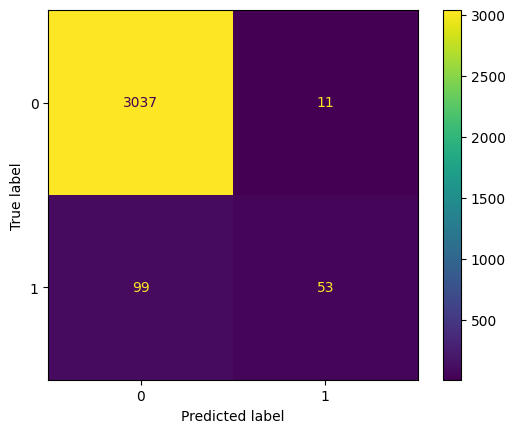

In [68]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_RF, display_labels=rf.classes_)
disp.plot()
plt.show()

AUC-PR RF: 0.6038733552631579
ROC-AUC RF: 0.8885
Matthews Correlation Coefficient (MCC) RF: 0.5243


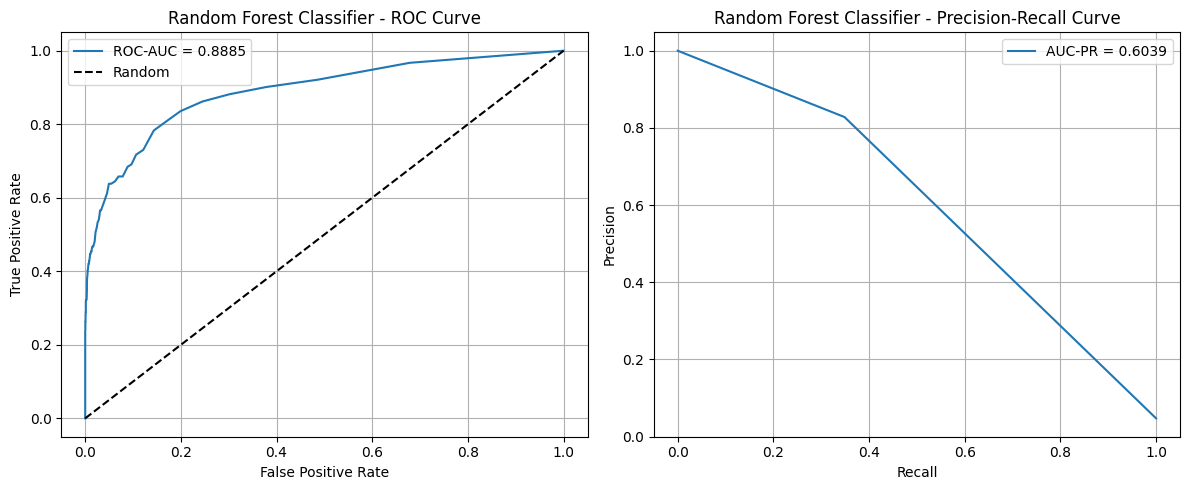

In [69]:
# ROC-AUC, AUC-PR and MCC for RF
precision_RF, recall_RF, _ = precision_recall_curve(y_test_rfe, y_pred_RF)
auc_pr_RF = auc(recall_RF, precision_RF)

y_pred_proba_RF = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_RF, tpr_roc_RF, _ = roc_curve(y_test_rfe, y_pred_proba_RF)
roc_auc_RF = auc(fpr_roc_RF, tpr_roc_RF)

mcc_RF = matthews_corrcoef(y_test_rfe, y_pred_RF)

print("AUC-PR RF:", auc_pr_RF)
print(f"ROC-AUC RF: {roc_auc_RF:.4f}")
print(f"Matthews Correlation Coefficient (MCC) RF: {mcc_RF:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_RF, tpr_roc_RF, label=f'ROC-AUC = {roc_auc_RF:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Random Forest Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_RF, precision_RF, label=f'AUC-PR = {auc_pr_RF:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Random Forest Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 10. SGD Classifier

In [70]:
# Initialize and train Model
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_rfe, y_train_rfe)

SGDClassifier(random_state=42)

In [71]:
# Make predictions
y_pred_SGD = sgd.predict(X_test_rfe)

In [72]:
# Evaluating the SGD model
accuracy_SGD = accuracy_score(y_test_rfe, y_pred_SGD)
conf_matrix_SGD = confusion_matrix(y_test_rfe, y_pred_SGD)
class_report_SGD = classification_report(y_test_rfe, y_pred_SGD)

TP_SGD = conf_matrix_SGD[1, 1]
FN_SGD = conf_matrix_SGD[1, 0]
FP_SGD = conf_matrix_SGD[0, 1]
TN_SGD = conf_matrix_SGD[0, 0]

TPR_SGD = TP_SGD / (TP_SGD + FN_SGD) if (TP_SGD + FN_SGD) > 0 else 0
FPR_SGD = FP_SGD / (FP_SGD + TN_SGD) if (FP_SGD + TN_SGD) > 0 else 0
balanced_accuracy_SGD = (TPR_SGD + (TN_SGD / (TN_SGD + FP_SGD))) / 2 if (TN_SGD + FP_SGD) > 0 else 0

print("Evaluation Metrics for SGD:")
print(f'Accuracy: {accuracy_SGD:.4f}')
print(f'True Positive Rate (TPR): {TPR_SGD:.4f}')
print(f'False Positive Rate (FPR): {FPR_SGD:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_SGD:.4f}')
print('\nClassification Report:')
print(class_report_SGD)

Evaluation Metrics for SGD:
Accuracy: 0.9537
True Positive Rate (TPR): 0.0526
False Positive Rate (FPR): 0.0013
Balanced Accuracy: 0.5257

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3048
           1       0.67      0.05      0.10       152

    accuracy                           0.95      3200
   macro avg       0.81      0.53      0.54      3200
weighted avg       0.94      0.95      0.93      3200



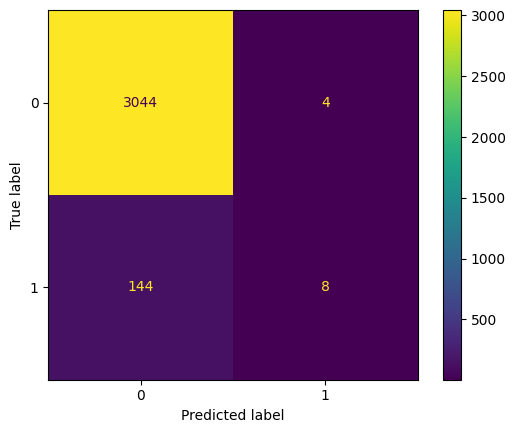

In [73]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SGD, display_labels=sgd.classes_)
disp.plot()
plt.show()

AUC-PR: 0.3821491228070175
ROC-AUC: 0.5777
Matthews Correlation Coefficient (MCC): 0.1786


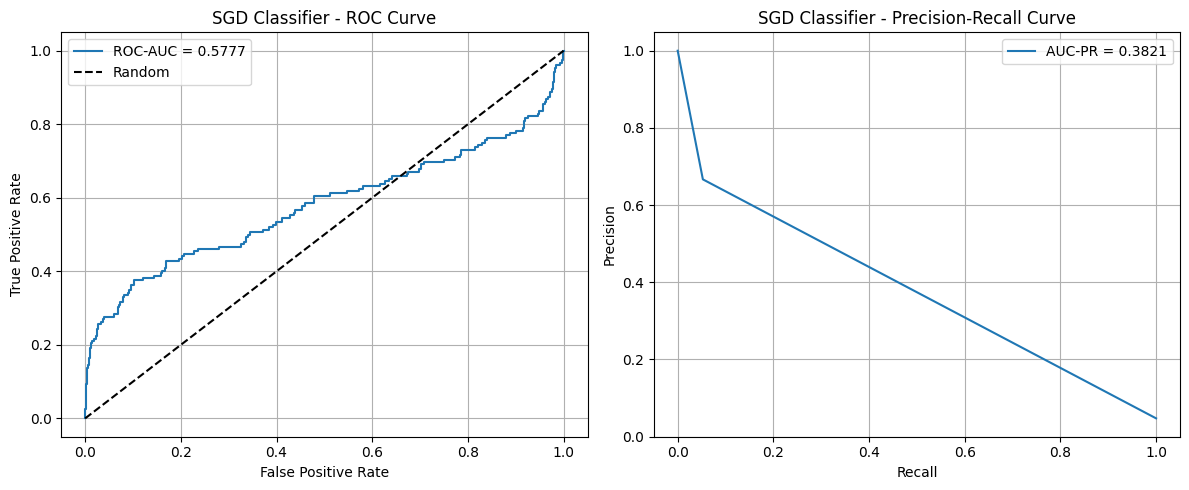

In [74]:
# ROC-AUC, AUC-PR and MCC for SGD
precision_SGD, recall_SGD, _ = precision_recall_curve(y_test_rfe, y_pred_SGD)
auc_pr_SGD = auc(recall_SGD, precision_SGD)
print("AUC-PR:", auc_pr_SGD)

decision_scores_SGD = sgd.decision_function(X_test_rfe)
fpr_roc_SGD, tpr_roc_SGD, _ = roc_curve(y_test_rfe, decision_scores_SGD)
roc_auc_SGD = auc(fpr_roc_SGD, tpr_roc_SGD)
print(f"ROC-AUC: {roc_auc_SGD:.4f}")

mcc_SGD = matthews_corrcoef(y_test_rfe, y_pred_SGD)
print(f"Matthews Correlation Coefficient (MCC): {mcc_SGD:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_SGD, tpr_roc_SGD, label=f'ROC-AUC = {roc_auc_SGD:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('SGD Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_SGD, precision_SGD, label=f'AUC-PR = {auc_pr_SGD:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('SGD Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 11. Extra Tree Classifier

In [75]:
# Initialize and train model
et = ExtraTreeClassifier(random_state=42)
et.fit(X_train_rfe, y_train_rfe)

ExtraTreeClassifier(random_state=42)

In [76]:
# Make prediction
y_pred_ET = et.predict(X_test_rfe)

In [77]:
# Evaluating the ET model
accuracy_ET = accuracy_score(y_test_rfe, y_pred_ET)
conf_matrix_ET = confusion_matrix(y_test_rfe, y_pred_ET)
class_report_ET = classification_report(y_test_rfe, y_pred_ET)

TP_ET = conf_matrix_ET[1, 1]
FN_ET = conf_matrix_ET[1, 0]
FP_ET = conf_matrix_ET[0, 1]
TN_ET = conf_matrix_ET[0, 0]

TPR_ET = TP_ET / (TP_ET + FN_ET) if (TP_ET + FN_ET) > 0 else 0
FPR_ET = FP_ET / (FP_ET + TN_ET) if (FP_ET + TN_ET) > 0 else 0
balanced_accuracy_ET = (TPR_ET + (TN_ET / (TN_ET + FP_ET))) / 2 if (TN_ET + FP_ET) > 0 else 0

print("Evaluation Metrics for ET:")
print(f'Accuracy: {accuracy_ET:.4f}')
print(f'True Positive Rate (TPR): {TPR_ET:.4f}')
print(f'False Positive Rate (FPR): {FPR_ET:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_ET:.4f}')
print('\nClassification Report:')
print(class_report_ET)

Evaluation Metrics for ET:
Accuracy: 0.9347
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0384
Balanced Accuracy: 0.6782

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3048
           1       0.34      0.39      0.36       152

    accuracy                           0.93      3200
   macro avg       0.65      0.68      0.67      3200
weighted avg       0.94      0.93      0.94      3200



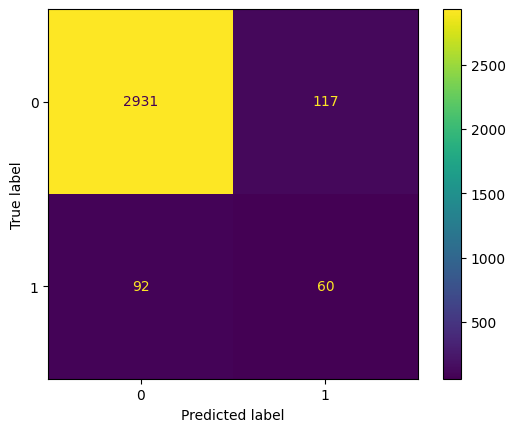

In [78]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ET, display_labels=et.classes_)
disp.plot()
plt.show()

AUC-PR: 0.38123494647636036
ROC-AUC: 0.8885
Matthews Correlation Coefficient (MCC): 0.3316


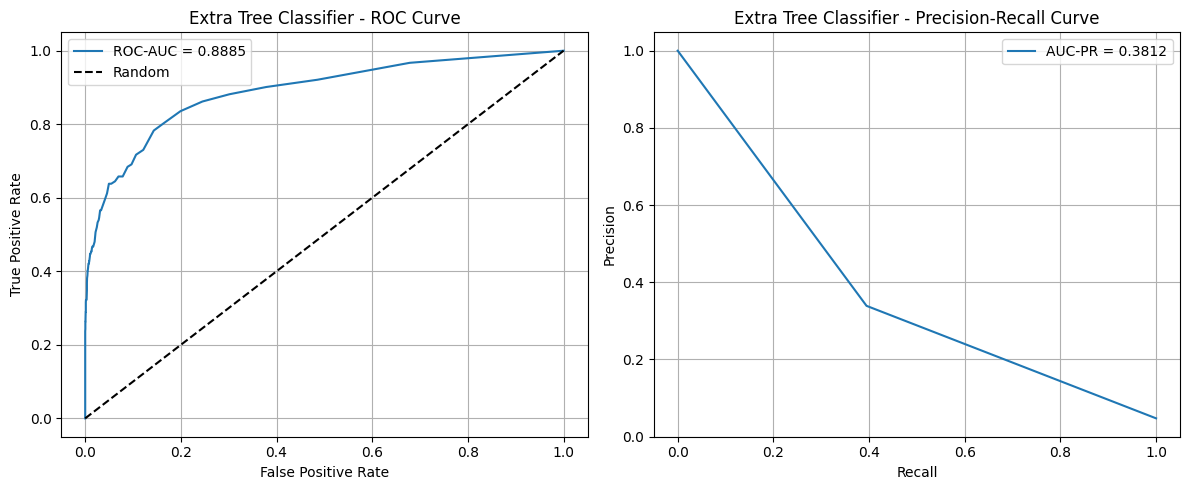

In [79]:
# ROC-AUC, AUC-PR and MCC for ET
precision_ET, recall_ET, _ = precision_recall_curve(y_test_rfe, y_pred_ET)
auc_pr_ET = auc(recall_ET, precision_ET)

y_pred_proba_ET = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_ET, tpr_roc_ET, _ = roc_curve(y_test_rfe, y_pred_proba_ET)
roc_auc_ET = auc(fpr_roc_ET, tpr_roc_ET)

mcc_ET = matthews_corrcoef(y_test_rfe, y_pred_ET)

print("AUC-PR:", auc_pr_ET)
print(f"ROC-AUC: {roc_auc_ET:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_ET:.4f}")

# ROC-AUC and AUC-PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_ET, tpr_roc_ET, label=f'ROC-AUC = {roc_auc_ET:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Extra Tree Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_ET, precision_ET, label=f'AUC-PR = {auc_pr_ET:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Extra Tree Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## 12. Extra Trees Classifier

In [80]:
# Initialize and train Model
ets = ExtraTreesClassifier(random_state=42)
ets.fit(X_train_rfe, y_train_rfe)

ExtraTreesClassifier(random_state=42)

In [81]:
# Make predictions
y_pred_ETS = ets.predict(X_test_rfe)

In [82]:
# Evaluating the ETS model
accuracy_ETS = accuracy_score(y_test_rfe, y_pred_ETS)
conf_matrix_ETS = confusion_matrix(y_test_rfe, y_pred_ETS)
class_report_ETS = classification_report(y_test_rfe, y_pred_ETS)

TP_ETS = conf_matrix_ETS[1, 1]
FN_ETS = conf_matrix_ETS[1, 0]
FP_ETS = conf_matrix_ETS[0, 1]
TN_ETS = conf_matrix_ETS[0, 0]

TPR_ETS = TP_ETS / (TP_ETS + FN_ETS) if (TP_ETS + FN_ETS) > 0 else 0
FPR_ETS = FP_ETS / (FP_ETS + TN_ETS) if (FP_ETS + TN_ETS) > 0 else 0
balanced_accuracy_ETS = (TPR_ETS + (TN_ETS / (TN_ETS + FP_ETS))) / 2 if (TN_ETS + FP_ETS) > 0 else 0

print("Evaluation Metrics for ETS:")
print(f'Accuracy: {accuracy_ETS:.4f}')
print(f'True Positive Rate (TPR): {TPR_ETS:.4f}')
print(f'False Positive Rate (FPR): {FPR_ETS:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_ETS:.4f}')
print('\nClassification Report:')
print(class_report_ETS)

Evaluation Metrics for ETS:
Accuracy: 0.9663
True Positive Rate (TPR): 0.3421
False Positive Rate (FPR): 0.0026
Balanced Accuracy: 0.6697

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.87      0.34      0.49       152

    accuracy                           0.97      3200
   macro avg       0.92      0.67      0.74      3200
weighted avg       0.96      0.97      0.96      3200



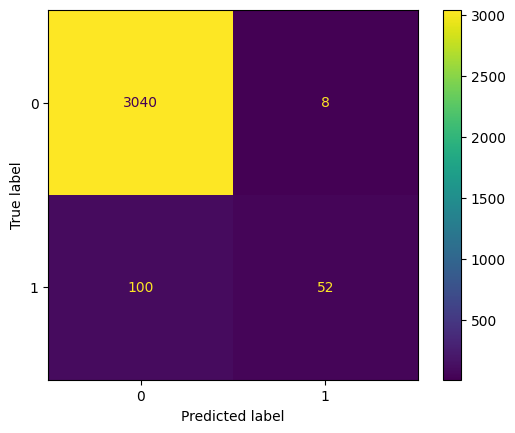

In [83]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ETS, display_labels=et.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6200109649122807
ROC-AUC: 0.8885
Matthews Correlation Coefficient (MCC): 0.5324


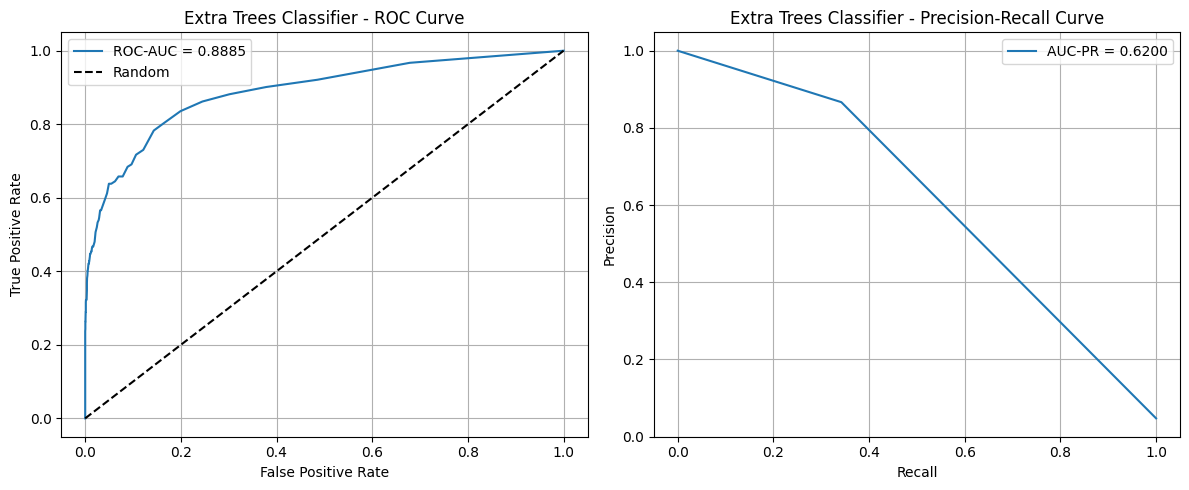

In [84]:
# ROC-AUC, AUC-PR and MCC for ETS
precision_ETS, recall_ETS, _ = precision_recall_curve(y_test_rfe, y_pred_ETS)
auc_pr_ETS = auc(recall_ETS, precision_ETS)

y_pred_proba_ETS = rf.predict_proba(X_test_rfe)[:, 1]
fpr_roc_ETS, tpr_roc_ETS, _ = roc_curve(y_test_rfe, y_pred_proba_ETS)
roc_auc_ETS = auc(fpr_roc_ETS, tpr_roc_ETS)

mcc_ETS = matthews_corrcoef(y_test_rfe, y_pred_ETS)

print("AUC-PR:", auc_pr_ETS)
print(f"ROC-AUC: {roc_auc_ETS:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_ETS:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr_roc_ETS, tpr_roc_ETS, label=f'ROC-AUC = {roc_auc_ETS:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Extra Trees Classifier - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall_ETS, precision_ETS, label=f'AUC-PR = {auc_pr_ETS:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Extra Trees Classifier - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

## SUMMARY

In [85]:
models_data = [
    ("Nearest Centroid", 1, accuracy_NC, balanced_accuracy_NC, roc_auc_NC, auc_pr_NC, mcc_NC, TPR_NC, FPR_NC),
    ("Decision Tree", 2, accuracy_DT, balanced_accuracy_DT, roc_auc_DT, auc_pr_DT, mcc_DT, TPR_DT, FPR_DT),
    ("Linear Discriminant Analysis", 3, accuracy_LDA, balanced_accuracy_LDA, roc_auc_LDA, auc_pr_LDA, mcc_LDA, TPR_LDA, FPR_LDA),
    ("Bagging Classifier", 4, accuracy_BAG, balanced_accuracy_BAG, roc_auc_BAG, auc_pr_BAG, mcc_BAG, TPR_BAG, FPR_BAG),
    ("Perceptron", 5, accuracy_PRC, balanced_accuracy_PRC, roc_auc_PRC, auc_pr_PRC, mcc_PRC, TPR_PRC, FPR_PRC),
    ("XGB Classifier", 6, accuracy_XGB, balanced_accuracy_XGB, roc_auc_XGB, auc_pr_XGB, mcc_XGB, TPR_XGB, FPR_XGB),
    ("LGBM Classifier", 7, accuracy_LGBM, balanced_accuracy_LGBM, roc_auc_LGBM, auc_pr_LGBM, mcc_LGBM, TPR_LGBM, FPR_LGBM),
    ("BernoulliNB", 8, accuracy_BNB, balanced_accuracy_BNB, roc_auc_BNB, auc_pr_BNB, mcc_BNB, TPR_BNB, FPR_BNB),
    ("Random Forest", 9, accuracy_RF, balanced_accuracy_RF, roc_auc_RF, auc_pr_RF, mcc_RF, TPR_RF, FPR_RF),
    ("SGD Classifier", 10, accuracy_SGD, balanced_accuracy_SGD, roc_auc_SGD, auc_pr_SGD, mcc_SGD, TPR_SGD, FPR_SGD),
    ("Extra Tree Classifier", 11, accuracy_ET, balanced_accuracy_ET, roc_auc_ET, auc_pr_ET, mcc_ET, TPR_ET, FPR_ET),
    ("Extra Trees Classifier", 12, accuracy_ETS, balanced_accuracy_ETS, roc_auc_ETS, auc_pr_ETS, mcc_ETS, TPR_ETS, FPR_ETS)
]

In [86]:
# SUMMARY COMPARISON
print("SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON")
print("Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions + standalone classifiers")

print(f"{'Model':<30} {'N_Models':<10} {'Accuracy':<10} {'Bal_Acc':<10} {'ROC-AUC':<10} {'AUC-PR':<10} {'MCC':<8} {'TPR':<8} {'FPR':<8}")

for model_name, n_models, acc, bal_acc, roc_auc, auc_pr_score, mcc, tpr, fpr in models_data:
    print(f"{model_name:<30} {n_models:<10} {acc:<10.4f} {bal_acc:<10.4f} {roc_auc:<10.4f} {auc_pr_score:<10.4f} {mcc:<8.4f} {tpr:<8.4f} {fpr:<8.4f}")

# Find best performing models
best_accuracy = max(models_data, key=lambda x: x[2])
best_balanced = max(models_data, key=lambda x: x[3])
best_roc_auc = max(models_data, key=lambda x: x[4])
best_auc_pr = max(models_data, key=lambda x: x[5])
best_mcc = max(models_data, key=lambda x: x[6])
best_tpr = max(models_data, key=lambda x: x[7])
best_fpr = min(models_data, key=lambda x: x[8])

print("\nBEST PERFORMING MODELS:")
print(f"Best Accuracy: {best_accuracy[0]} - {best_accuracy[2]:.4f}")
print(f"Best Balanced Accuracy: {best_balanced[0]} - {best_balanced[3]:.4f}")
print(f"Best ROC-AUC: {best_roc_auc[0]} - {best_roc_auc[4]:.4f}")
print(f"Best AUC-PR: {best_auc_pr[0]} - {best_auc_pr[5]:.4f}")
print(f"Best MCC: {best_mcc[0]} - {best_mcc[6]:.4f}")
print(f"Best True Positive Rate (TPR): {best_tpr[0]} - {best_tpr[7]:.4f}")
print(f"Lowest False Positive Rate (FPR): {best_fpr[0]} - {best_fpr[8]:.4f}")

SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON
Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions + standalone classifiers
Model                          N_Models   Accuracy   Bal_Acc    ROC-AUC    AUC-PR     MCC      TPR      FPR     
Nearest Centroid               1          0.9022     0.7330     0.7451     0.4107     0.3272   0.5461   0.0801  
Decision Tree                  2          0.9359     0.7038     0.7038     0.4167     0.3678   0.4474   0.0397  
Linear Discriminant Analysis   3          0.9575     0.6995     0.7954     0.5075     0.4659   0.4145   0.0154  
Bagging Classifier             4          0.9628     0.6836     0.8218     0.5542     0.4972   0.3750   0.0079  
Perceptron                     5          0.9384     0.6583     0.6597     0.3653     0.3175   0.3487   0.0322  
XGB Classifier                 6          0.9659     0.6946     0.8849     0.6014     0.5402   0.3947   0.0056  
LGBM Classifier                7          0.962

# Stacking Ensemble Models

In [87]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [88]:
# FULL MODEL
base_models = [
    ('nc', NearestCentroid()),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('bagging', BaggingClassifier(random_state=42)),
    ('perceptron', Perceptron(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('bnb', BernoulliNB()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('etcs', ExtraTreesClassifier(random_state=42))
]

In [89]:
# Meta-learner
meta_learner = LogisticRegression()

In [90]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

In [91]:
# Train model
stacking_model.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('nc', NearestCentroid()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis()),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('perceptron', Perceptron(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsa...
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('bnb', BernoulliNB()),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('etcs', ExtraTreesClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [92]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test_rfe)

In [93]:
# Evaluating the model
accuracy_stack = accuracy_score(y_test_rfe, y_pred_stack)
conf_matrix_stack = confusion_matrix(y_test_rfe, y_pred_stack)
class_report_stack = classification_report(y_test_rfe, y_pred_stack)

TP = conf_matrix_stack[1, 1]
FN = conf_matrix_stack[1, 0]
FP = conf_matrix_stack[0, 1]
TN = conf_matrix_stack[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("FULL MODEL - All Models (12 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_stack:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack)

FULL MODEL - All Models (12 models)
Evaluation Metrics:
Accuracy: 0.9672
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.7015

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



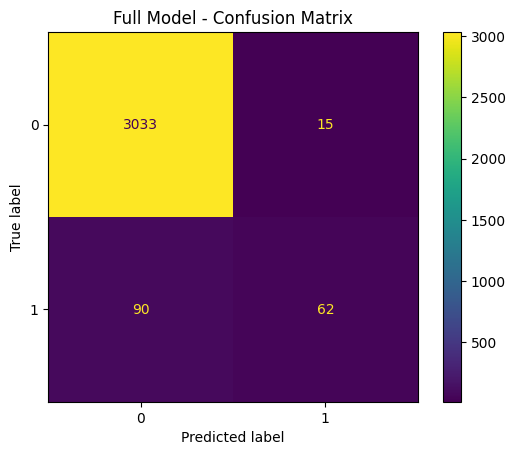

In [94]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack, display_labels=stacking_model.classes_)
disp.plot()
plt.title('Full Model - Confusion Matrix')
plt.show()

ROC-AUC: 0.9041
AUC-PR: 0.6206
Matthews Correlation Coefficient (MCC): 0.5593


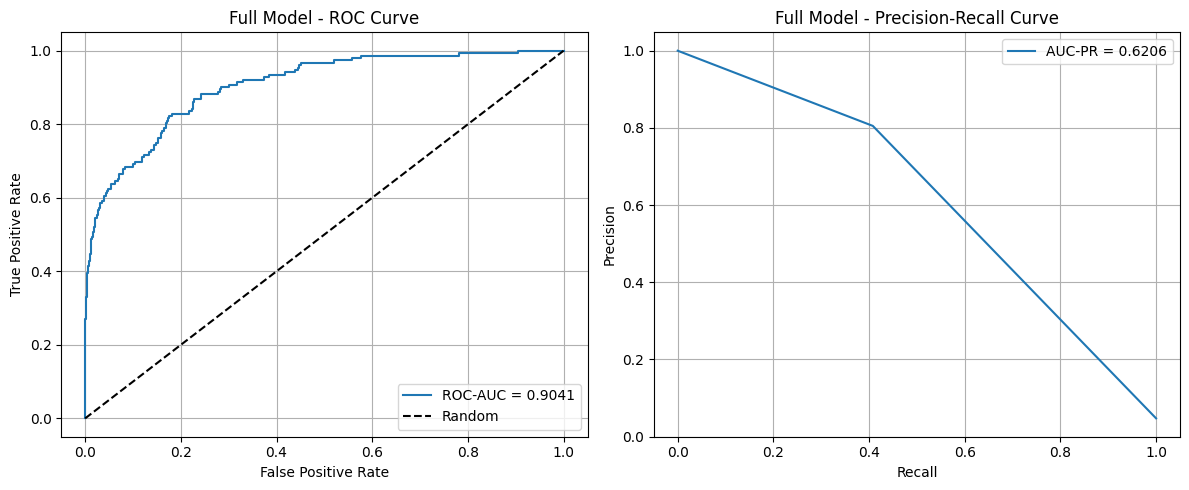

In [95]:
# ROC-AUC, AUC-PR and MCC
y_pred_proba_full = stacking_model.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_full)
roc_auc_full = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack)
auc_pr = auc(recall, precision)

mcc_full = matthews_corrcoef(y_test_rfe, y_pred_stack)

print(f"ROC-AUC: {roc_auc_full:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_full:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_full:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Full Model - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Full Model - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# SHAP - Stacking Ensemble

In [96]:
import shap

In [97]:
# Meta-learner
meta_learner = stacking_model.final_estimator_

In [98]:
# Transformed features
X_test_meta = stacking_model.transform(X_test_rfe)

In [99]:
# Feature Names
base_model_names = [name for name, _ in base_models]
feature_names = []

for model_name in base_model_names:
    feature_names.append(f"{model_name}_prediction")

In [100]:
# DataFrame
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

In [101]:
# SHAP explainer
explainer = shap.Explainer(meta_learner, X_test_meta_df)
shap_values = explainer(X_test_meta_df)

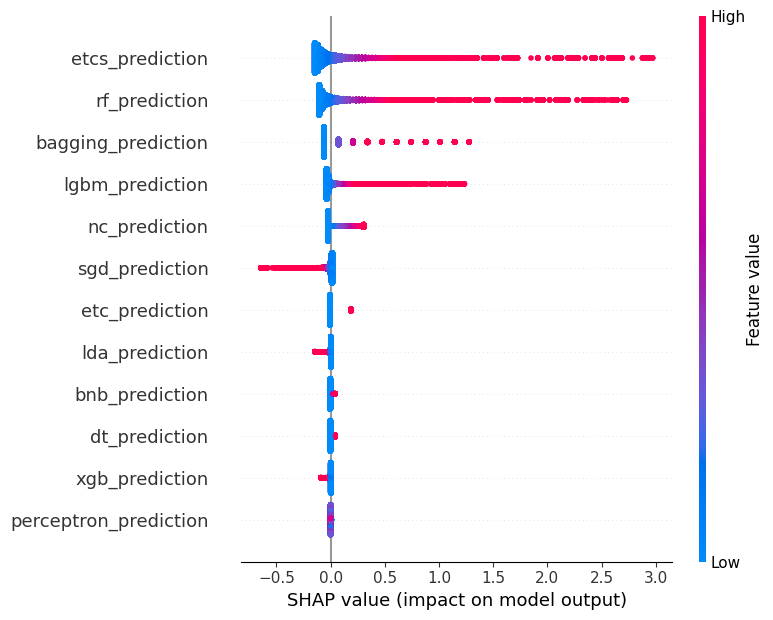

In [102]:
# Subsample
sample_indices = np.random.choice(len(X_test_meta_df), size=16000, replace=True)
shap_values_sampled = shap_values[sample_indices]
X_test_meta_sampled = X_test_meta_df.iloc[sample_indices]

shap.summary_plot(shap_values_sampled, X_test_meta_sampled)

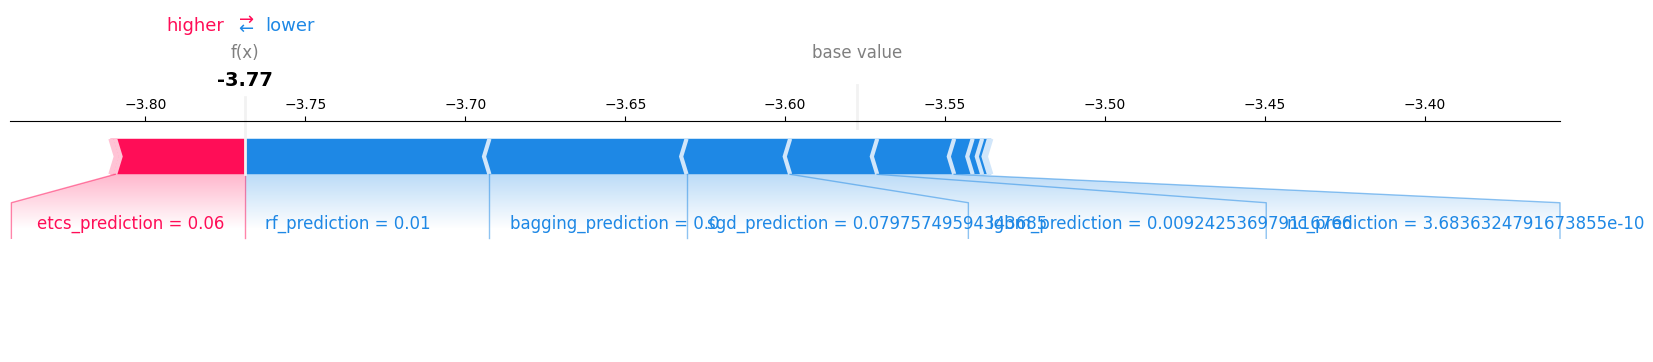

In [103]:
# Force Plot
idx = np.random.randint(len(X_test_meta_sampled))
shap.force_plot(explainer.expected_value, shap_values_sampled[idx].values, X_test_meta_sampled.iloc[idx], matplotlib=True)

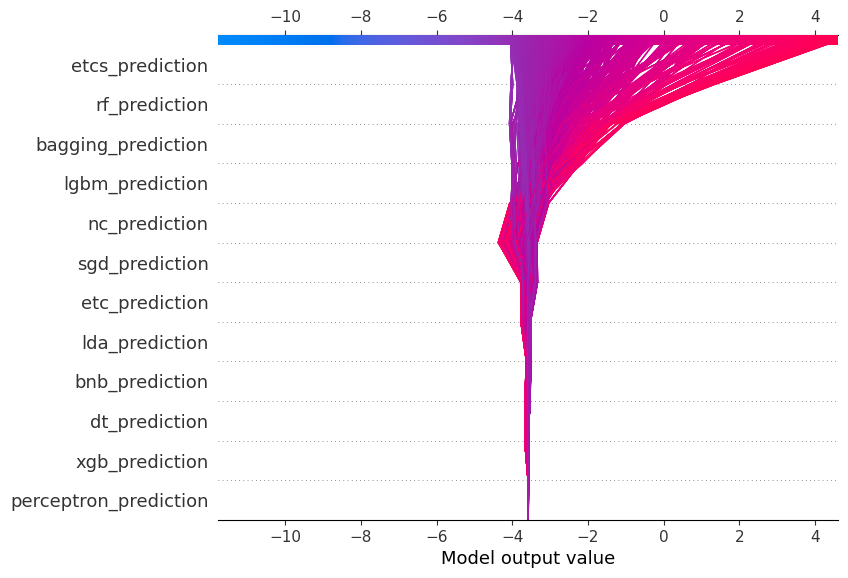

In [104]:
# Decision Plot
shap.decision_plot(explainer.expected_value, shap_values_sampled.values, X_test_meta_sampled, ignore_warnings=True)
plt.show()

# SHAP - Base Models

## XGB Classifier

In [105]:
# SHAP explainer
explainer = shap.Explainer(xgb, X_train_rfe)

In [106]:
# SHAP values
shap_values = explainer(X_test_rfe)

100%|===================| 3187/3200 [00:42<00:00]        

In [107]:
# Feature names
selected_feature_names = X.columns[selector.support_]

In [108]:
# DataFrame
X_test_rfe_df = pd.DataFrame(X_test_rfe, columns=selected_feature_names)

In [109]:
# Subsample for plotting
sample_indices = np.random.choice(len(X_test_rfe_df), size=16000, replace=True)
X_test_sampled = X_test_rfe_df.iloc[sample_indices]
shap_values_sampled = shap_values[sample_indices]

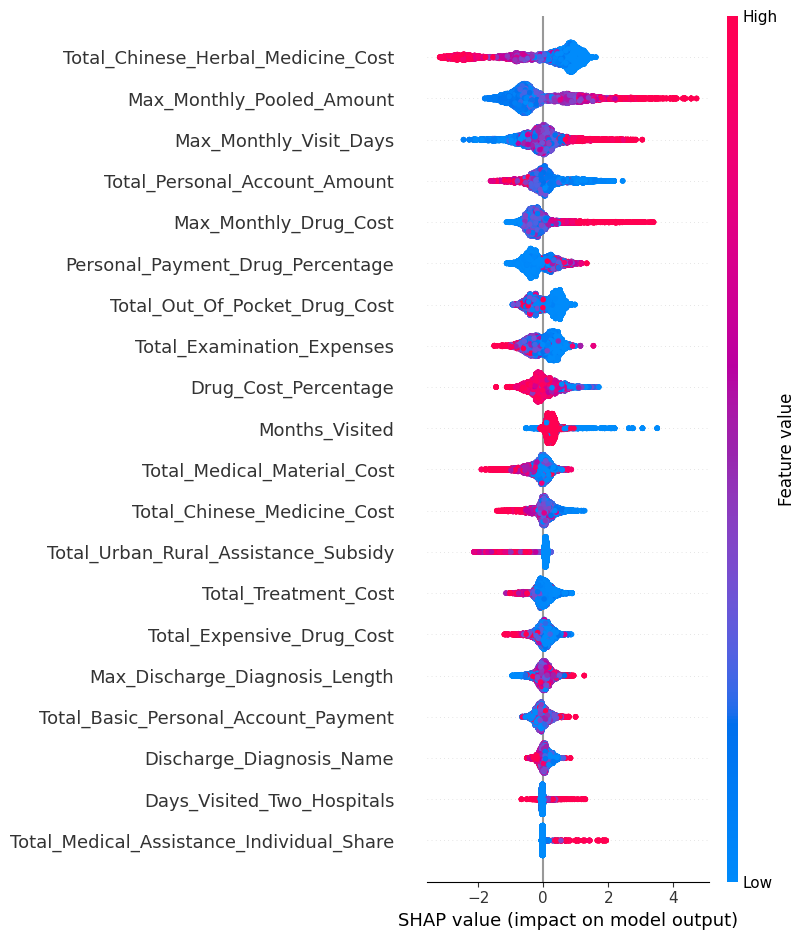

In [110]:
# SHAP Summary Plot
shap.summary_plot(shap_values_sampled, X_test_sampled)

# Reduced Stacking Ensembles

## 1. Reduced 1 - ETCS, RF, BAGGING, LGBM

In [111]:
# REDUCED MODEL 1: Core performers (SHAP > 0.5) - etcs, rf, bagging, lgbm
reduced1_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [112]:
# Meta-learner
meta_learner = LogisticRegression()

In [113]:
# Stacking Classifier
stacking_model_reduced1 = StackingClassifier(estimators=reduced1_models, final_estimator=meta_learner, cv=5)

In [114]:
# Train model
stacking_model_reduced1.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005458 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [115]:
# Make predictions
y_pred_stack_reduced1 = stacking_model_reduced1.predict(X_test_rfe)

In [116]:
# Evaluating Reduced Model 1
accuracy_reduced1 = accuracy_score(y_test_rfe, y_pred_stack_reduced1)
conf_matrix_reduced1 = confusion_matrix(y_test_rfe, y_pred_stack_reduced1)
class_report_reduced1 = classification_report(y_test_rfe, y_pred_stack_reduced1)

TP = conf_matrix_reduced1[1, 1]
FN = conf_matrix_reduced1[1, 0]
FP = conf_matrix_reduced1[0, 1]
TN = conf_matrix_reduced1[0, 0]

TPR_reduced1 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced1 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced1 = (TPR_reduced1 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 1 - Core Performers (4 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced1:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced1:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced1:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced1:.4f}')
print('\nClassification Report:')
print(class_report_reduced1)

REDUCED MODEL 1 - Core Performers (4 models)
Evaluation Metrics:
Accuracy: 0.9663
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6916

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



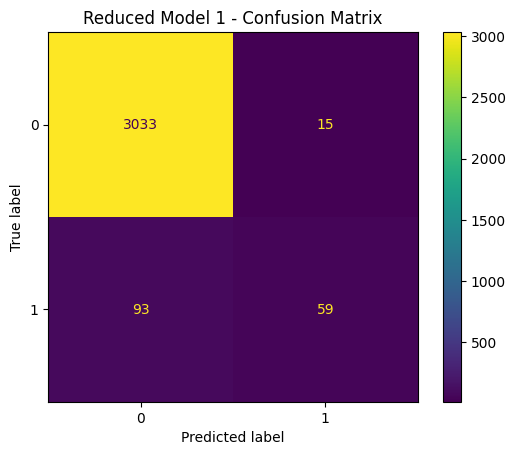

In [117]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced1, display_labels=stacking_model_reduced1.classes_)
disp.plot()
plt.title('Reduced Model 1 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9054
AUC-PR: 0.6073
Matthews Correlation Coefficient (MCC): 0.5424


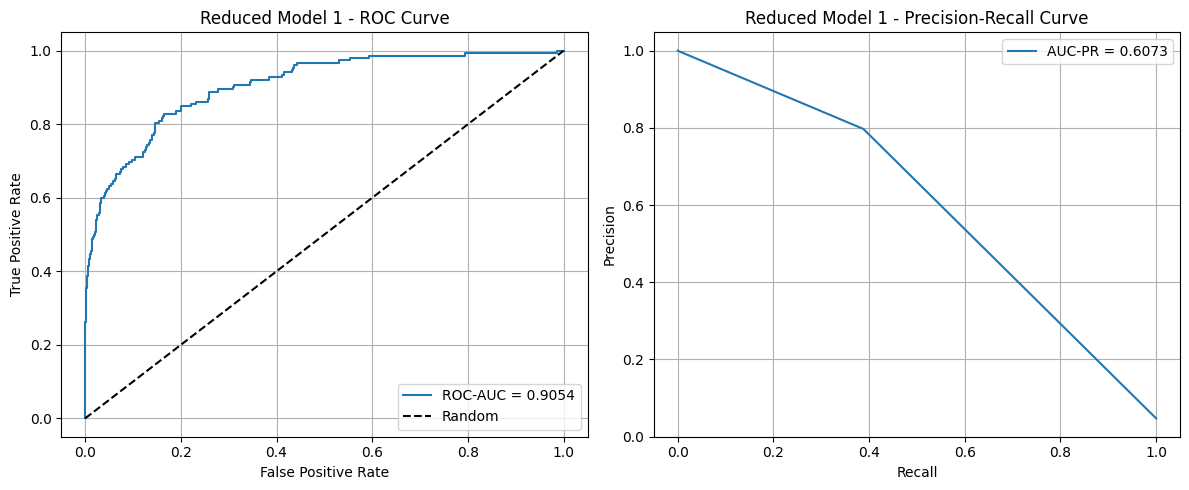

In [118]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced1 = stacking_model_reduced1.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced1)
roc_auc_reduced1 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced1)
auc_pr_reduced1 = auc(recall, precision)

mcc_reduced1 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced1)

print(f"ROC-AUC: {roc_auc_reduced1:.4f}")
print(f"AUC-PR: {auc_pr_reduced1:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced1:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced1:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 1 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced1:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 1 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. Reduced 2 - Core + next best (nc)

In [119]:
# REDUCED MODEL 2
reduced2_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [120]:
# Meta-learner
meta_learner = LogisticRegression()

In [121]:
# Stacking Classifier
stacking_model_reduced2 = StackingClassifier(estimators=reduced2_models, final_estimator=meta_learner, cv=5)

In [122]:
# Train model
stacking_model_reduced2.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [123]:
# Make predictions
y_pred_stack_reduced2 = stacking_model_reduced2.predict(X_test_rfe)

In [124]:
# Evaluating the model
accuracy_reduced2 = accuracy_score(y_test_rfe, y_pred_stack_reduced2)
conf_matrix_reduced2 = confusion_matrix(y_test_rfe, y_pred_stack_reduced2)
class_report_reduced2 = classification_report(y_test_rfe, y_pred_stack_reduced2)

TP = conf_matrix_reduced2[1, 1]
FN = conf_matrix_reduced2[1, 0]
FP = conf_matrix_reduced2[0, 1]
TN = conf_matrix_reduced2[0, 0]

TPR_reduced2 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced2 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced2 = (TPR_reduced2 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 2 - Core + NC + KNN)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced2:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced2:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced2:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced2:.4f}')
print('\nClassification Report:')
print(class_report_reduced2)

REDUCED MODEL 2 - Core + NC + KNN)
Evaluation Metrics:
Accuracy: 0.9663
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.6947

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.79      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



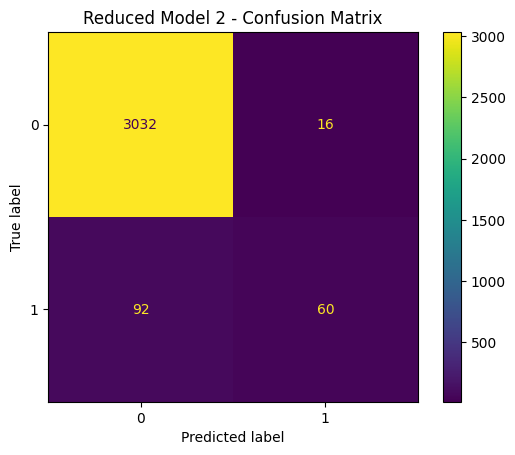

In [125]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced2, display_labels=stacking_model_reduced2.classes_)
disp.plot()
plt.title('Reduced Model 2 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9043
AUC-PR: 0.6065
Matthews Correlation Coefficient (MCC): 0.5441


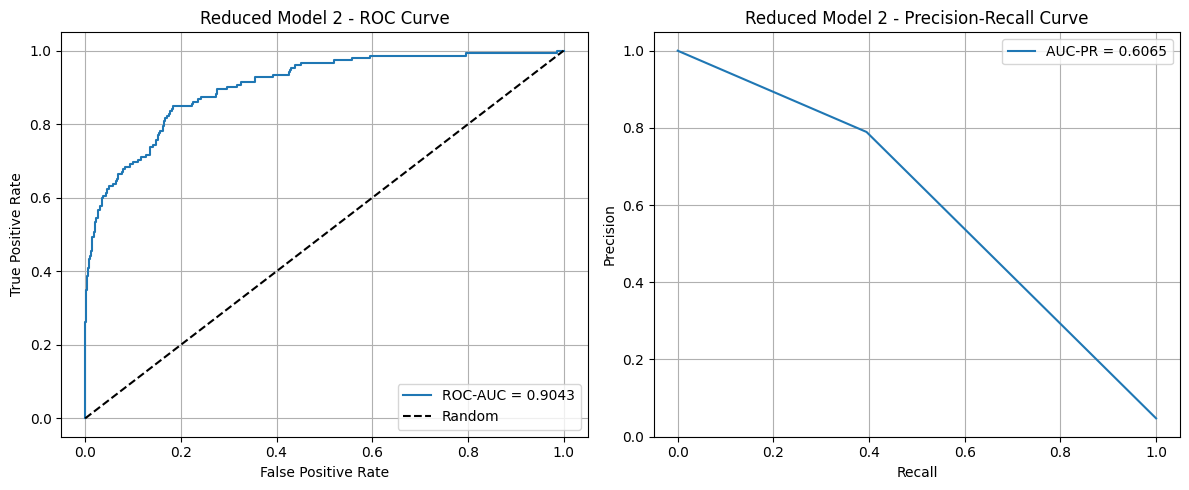

In [126]:
# ROC-AUC, AUC-PR and MCC
y_pred_proba_reduced2 = stacking_model_reduced2.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced2)
roc_auc_reduced2 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced2)
auc_pr_reduced2 = auc(recall, precision)

mcc_reduced2 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced2)

print(f"ROC-AUC: {roc_auc_reduced2:.4f}")
print(f"AUC-PR: {auc_pr_reduced2:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced2:.4f}")

# ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced2:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 2 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced2:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 2 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 3 - Core + next 2 best (nc, sgd)

In [127]:
# REDUCED MODEL 3
reduced3_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42))
]

In [128]:
# Meta-learner
meta_learner = LogisticRegression()

In [129]:
# Stacking Classifier
stacking_model_reduced3 = StackingClassifier(estimators=reduced3_models, final_estimator=meta_learner, cv=5)

In [130]:
# Train model
stacking_model_reduced3.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42))],
                   final_estimator=LogisticRegression())

In [131]:
# Make predictions
y_pred_stack_reduced3 = stacking_model_reduced3.predict(X_test_rfe)

In [132]:
# Evaluating Reduced Model 3
accuracy_reduced3 = accuracy_score(y_test_rfe, y_pred_stack_reduced3)
conf_matrix_reduced3 = confusion_matrix(y_test_rfe, y_pred_stack_reduced3)
class_report_reduced3 = classification_report(y_test_rfe, y_pred_stack_reduced3)

TP = conf_matrix_reduced3[1, 1]
FN = conf_matrix_reduced3[1, 0]
FP = conf_matrix_reduced3[0, 1]
TN = conf_matrix_reduced3[0, 0]

TPR_reduced3 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced3 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced3 = (TPR_reduced3 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 3 - Core + NC + KNN + SGD (7 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced3:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced3:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced3:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced3:.4f}')
print('\nClassification Report:')
print(class_report_reduced3)

REDUCED MODEL 3 - Core + NC + KNN + SGD (7 models)
Evaluation Metrics:
Accuracy: 0.9666
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6949

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.89      0.69      0.76      3200
weighted avg       0.96      0.97      0.96      3200



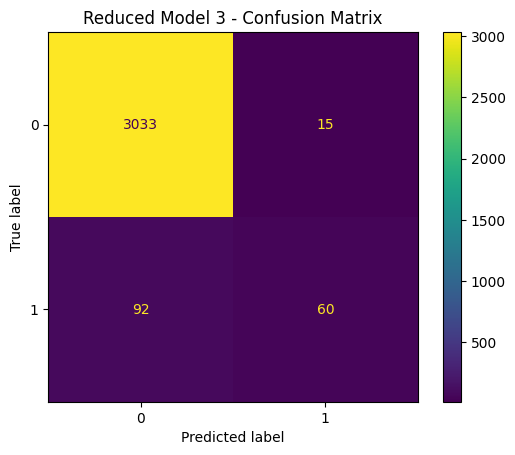

In [133]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced3, display_labels=stacking_model_reduced3.classes_)
disp.plot()
plt.title('Reduced Model 3 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9048
AUC-PR: 0.6117
Matthews Correlation Coefficient (MCC): 0.5481


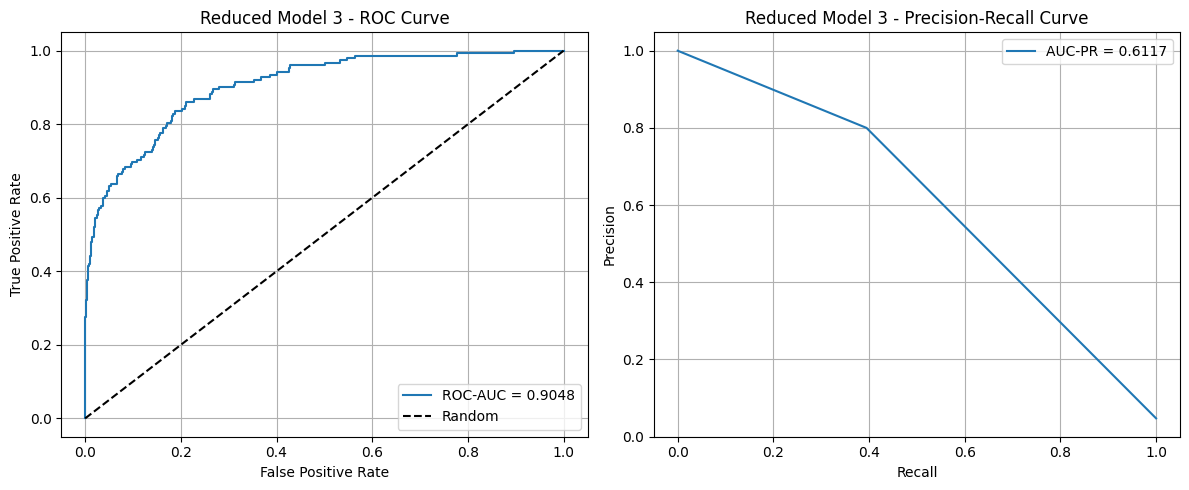

In [134]:
# ROC-AUC and AUC-PR and MCC
y_pred_proba_reduced3 = stacking_model_reduced3.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced3)
roc_auc_reduced3 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced3)
auc_pr_reduced3 = auc(recall, precision)

mcc_reduced3 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced3)

print(f"ROC-AUC: {roc_auc_reduced3:.4f}")
print(f"AUC-PR: {auc_pr_reduced3:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced3:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced3:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 3 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced3:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 3 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 4 - Core + next 3 best (nc, sgd, etc)

In [135]:
# REDUCED MODEL 4
reduced4_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42))
]

In [136]:
# Meta-learner
meta_learner = LogisticRegression()

In [137]:
# Stacking Classifier
stacking_model_reduced4 = StackingClassifier(estimators=reduced4_models, final_estimator=meta_learner, cv=5)

In [139]:
# Train model
stacking_model_reduced4.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [140]:
# Make predictions
y_pred_stack_reduced4 = stacking_model_reduced4.predict(X_test_rfe)

In [141]:
# Evaluating Reduced Model 4
accuracy_reduced4 = accuracy_score(y_test_rfe, y_pred_stack_reduced4)
conf_matrix_reduced4 = confusion_matrix(y_test_rfe, y_pred_stack_reduced4)
class_report_reduced4 = classification_report(y_test_rfe, y_pred_stack_reduced4)

TP = conf_matrix_reduced4[1, 1]
FN = conf_matrix_reduced4[1, 0]
FP = conf_matrix_reduced4[0, 1]
TN = conf_matrix_reduced4[0, 0]

TPR_reduced4 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced4 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced4 = (TPR_reduced4 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 4 - Core + NC + KNN + SGD + ETC (8 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced4:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced4:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced4:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced4:.4f}')
print('\nClassification Report:')
print(class_report_reduced4)

REDUCED MODEL 4 - Core + NC + KNN + SGD + ETC (8 models)
Evaluation Metrics:
Accuracy: 0.9672
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.7015

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



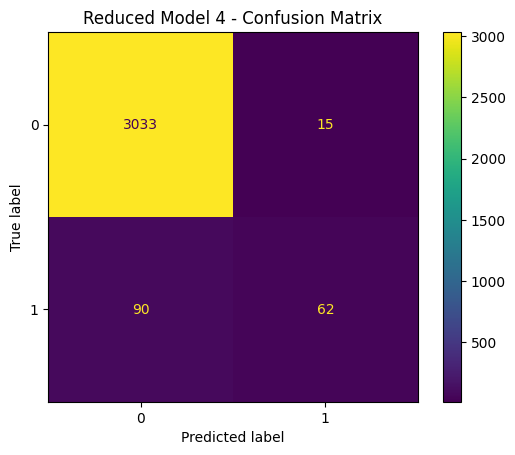

In [142]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced4, display_labels=stacking_model_reduced4.classes_)
disp.plot()
plt.title('Reduced Model 4 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9051
AUC-PR: 0.6206
Matthews Correlation Coefficient (MCC): 0.5593


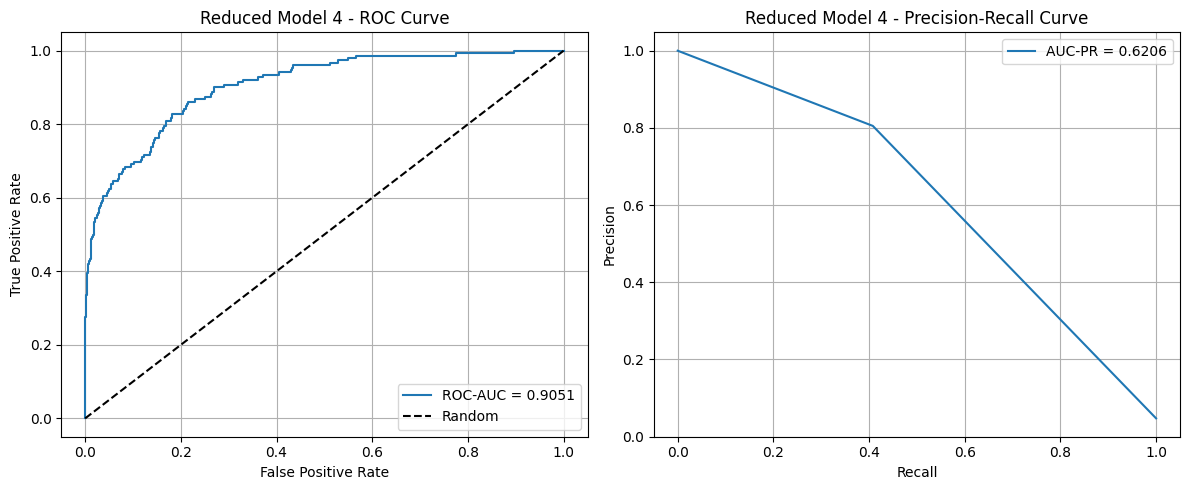

In [143]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced4 = stacking_model_reduced4.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced4)
roc_auc_reduced4 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced4)
auc_pr_reduced4 = auc(recall, precision)

mcc_reduced4 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced4)

print(f"ROC-AUC: {roc_auc_reduced4:.4f}")
print(f"AUC-PR: {auc_pr_reduced4:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced4:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced4:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 4 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced4:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 4 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 5 - Core + next 4 best (nc, sgd, etc, lda)

In [144]:
# REDUCED MODEL 5
reduced5_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis())
]

In [145]:
# Meta-learner
meta_learner = LogisticRegression()

In [146]:
# Stacking Classifier
stacking_model_reduced5 = StackingClassifier(estimators=reduced5_models, final_estimator=meta_learner, cv=5)

In [147]:
# Train model
stacking_model_reduced5.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis())],
                   final_estimator=LogisticRegression())

In [148]:
# Make predictions
y_pred_stack_reduced5 = stacking_model_reduced5.predict(X_test_rfe)

In [149]:
# Evaluating Reduced Model 5
accuracy_reduced5 = accuracy_score(y_test_rfe, y_pred_stack_reduced5)
conf_matrix_reduced5 = confusion_matrix(y_test_rfe, y_pred_stack_reduced5)
class_report_reduced5 = classification_report(y_test_rfe, y_pred_stack_reduced5)

TP = conf_matrix_reduced5[1, 1]
FN = conf_matrix_reduced5[1, 0]
FP = conf_matrix_reduced5[0, 1]
TN = conf_matrix_reduced5[0, 0]

TPR_reduced5 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced5 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced5 = (TPR_reduced5 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 5 - Core + NC + KNN + SGD + ETC + LDA (9 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced5:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced5:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced5:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced5:.4f}')
print('\nClassification Report:')
print(class_report_reduced5)

REDUCED MODEL 5 - Core + NC + KNN + SGD + ETC + LDA (9 models)
Evaluation Metrics:
Accuracy: 0.9669
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.7013

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.79      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.88      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



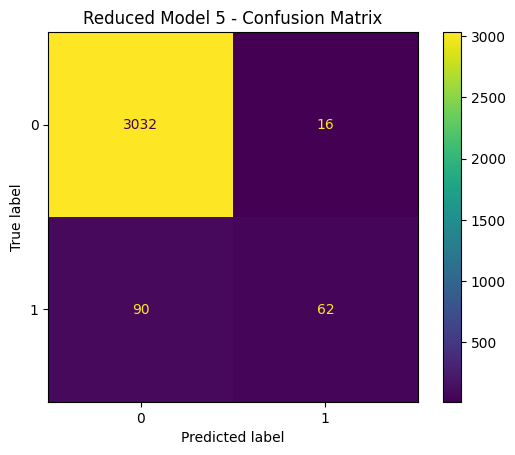

In [150]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced5, display_labels=stacking_model_reduced5.classes_)
disp.plot()
plt.title('Reduced Model 5 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9047
AUC-PR: 0.6154
Matthews Correlation Coefficient (MCC): 0.5554


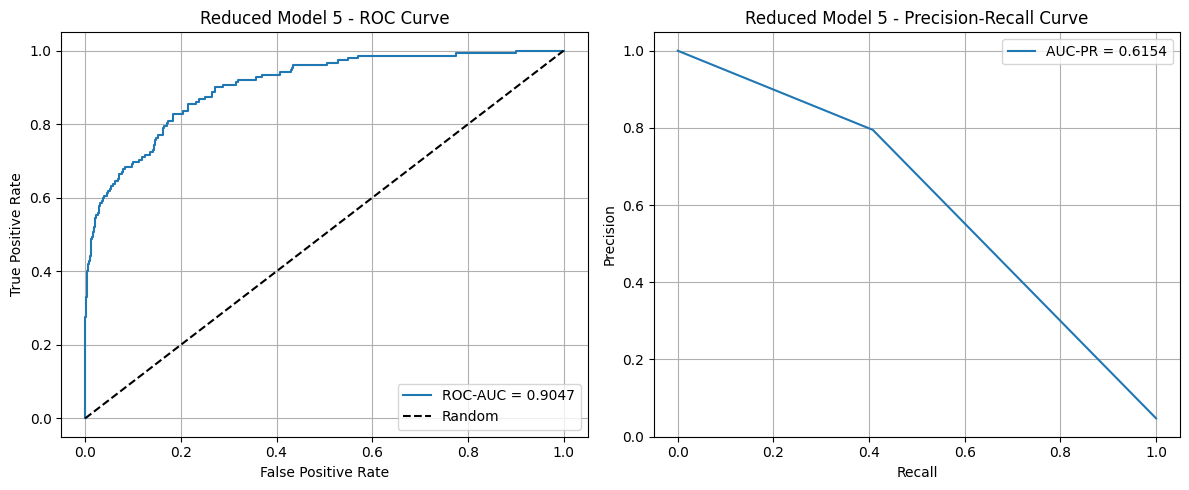

In [151]:
# ROC-AUC and AUC-PR and MCC
y_pred_proba_reduced5 = stacking_model_reduced5.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced5)
roc_auc_reduced5 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced5)
auc_pr_reduced5 = auc(recall, precision)
mcc_reduced5 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced5)

print(f"ROC-AUC: {roc_auc_reduced5:.4f}")
print(f"AUC-PR: {auc_pr_reduced5:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced5:.4f}")

# ROC and Precision Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced5:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 5 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced5:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 5 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 6 - Core + next 5 best (nc, sgd, etc, lda, xgb)

In [152]:
# REDUCED MODEL 6
reduced6_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

In [153]:
# Meta-learner
meta_learner = LogisticRegression()

In [154]:
# Stacking Classifier
stacking_model_reduced6 = StackingClassifier(estimators=reduced6_models, final_estimator=meta_learner, cv=5)

In [155]:
# Train model
stacking_model_reduced6.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('lda',...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))],
                   final_estimator=LogisticRegression())

In [156]:
# Make predictions
y_pred_stack_reduced6 = stacking_model_reduced6.predict(X_test_rfe)

In [157]:
# Evaluating Reduced Model 6
accuracy_reduced6 = accuracy_score(y_test_rfe, y_pred_stack_reduced6)
conf_matrix_reduced6 = confusion_matrix(y_test_rfe, y_pred_stack_reduced6)
class_report_reduced6 = classification_report(y_test_rfe, y_pred_stack_reduced6)

TP = conf_matrix_reduced6[1, 1]
FN = conf_matrix_reduced6[1, 0]
FP = conf_matrix_reduced6[0, 1]
TN = conf_matrix_reduced6[0, 0]

TPR_reduced6 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced6 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced6 = (TPR_reduced6 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 6 - Core + NC + KNN + SGD + ETC + LDA + XGB (10 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced6:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced6:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced6:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced6:.4f}')
print('\nClassification Report:')
print(class_report_reduced6)

REDUCED MODEL 6 - Core + NC + KNN + SGD + ETC + LDA + XGB (10 models)
Evaluation Metrics:
Accuracy: 0.9669
True Positive Rate (TPR): 0.4013
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6982

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.40      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



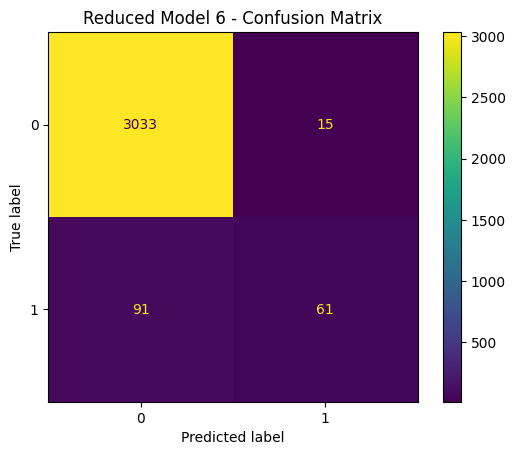

In [158]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced6, display_labels=stacking_model_reduced6.classes_)
disp.plot()
plt.title('Reduced Model 6 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9040
AUC-PR: 0.6162
Matthews Correlation Coefficient (MCC): 0.5537


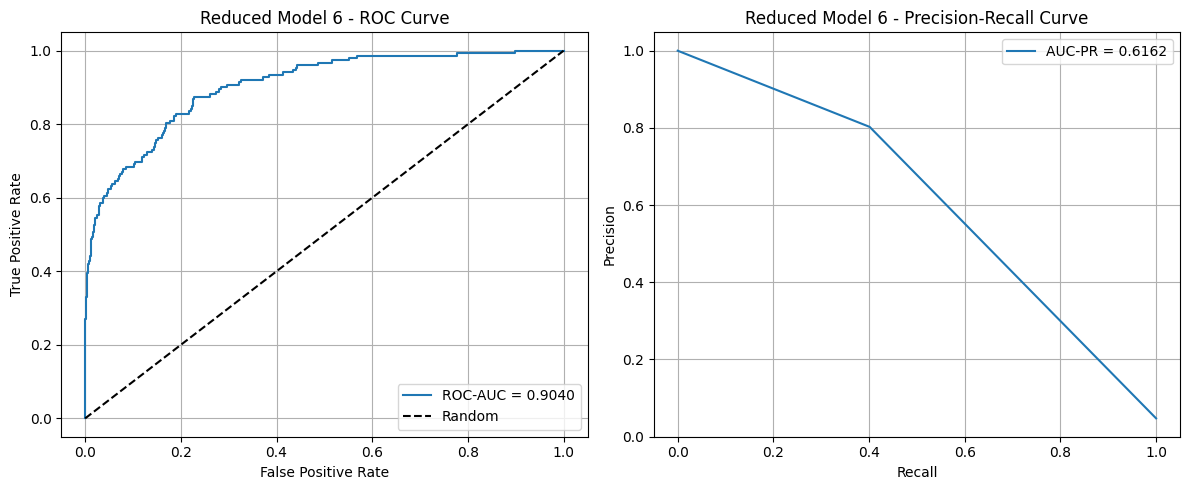

In [159]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced6 = stacking_model_reduced6.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced6)
roc_auc_reduced6 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced6)
auc_pr_reduced6 = auc(recall, precision)

mcc_reduced6 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced6)

print(f"ROC-AUC: {roc_auc_reduced6:.4f}")
print(f"AUC-PR: {auc_pr_reduced6:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced6:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced6:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 6 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced6:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 6 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 7 - Core + next 6 best (nc, sgd, etc, lda, xgb, bnb)

In [160]:
# REDUCED MODEL 7
reduced7_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('bnb', BernoulliNB())
]

In [161]:
# Meta-learner
meta_learner = LogisticRegression()

In [162]:
# Stacking Classifier
stacking_model_reduced7 = StackingClassifier(estimators=reduced7_models, final_estimator=meta_learner, cv=5)

In [163]:
# Train model
stacking_model_reduced7.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001737 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('lda',...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('bnb', BernoulliNB())],
                   final_estimator=LogisticRegression())

In [164]:
# Make predictions
y_pred_stack_reduced7 = stacking_model_reduced7.predict(X_test_rfe)

In [165]:
# Evaluating Reduced Model 7
accuracy_reduced7 = accuracy_score(y_test_rfe, y_pred_stack_reduced7)
conf_matrix_reduced7 = confusion_matrix(y_test_rfe, y_pred_stack_reduced7)
class_report_reduced7 = classification_report(y_test_rfe, y_pred_stack_reduced7)

TP = conf_matrix_reduced7[1, 1]
FN = conf_matrix_reduced7[1, 0]
FP = conf_matrix_reduced7[0, 1]
TN = conf_matrix_reduced7[0, 0]

TPR_reduced7 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced7 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced7 = (TPR_reduced7 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 7 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB (11 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced7:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced7:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced7:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced7:.4f}')
print('\nClassification Report:')
print(class_report_reduced7)

REDUCED MODEL 7 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB (11 models)
Evaluation Metrics:
Accuracy: 0.9672
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.7015

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



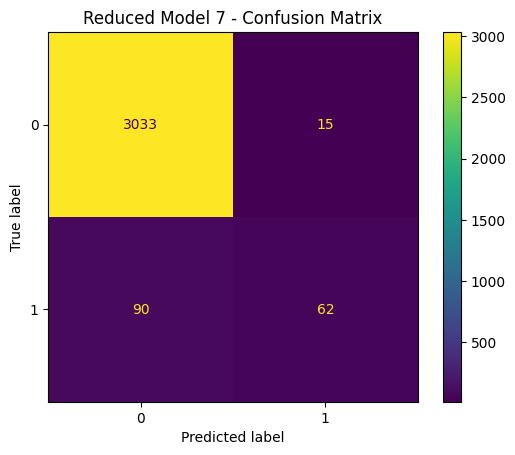

In [166]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced7, display_labels=stacking_model_reduced7.classes_)
disp.plot()
plt.title('Reduced Model 7 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9037
AUC-PR: 0.6206
Matthews Correlation Coefficient (MCC): 0.5593


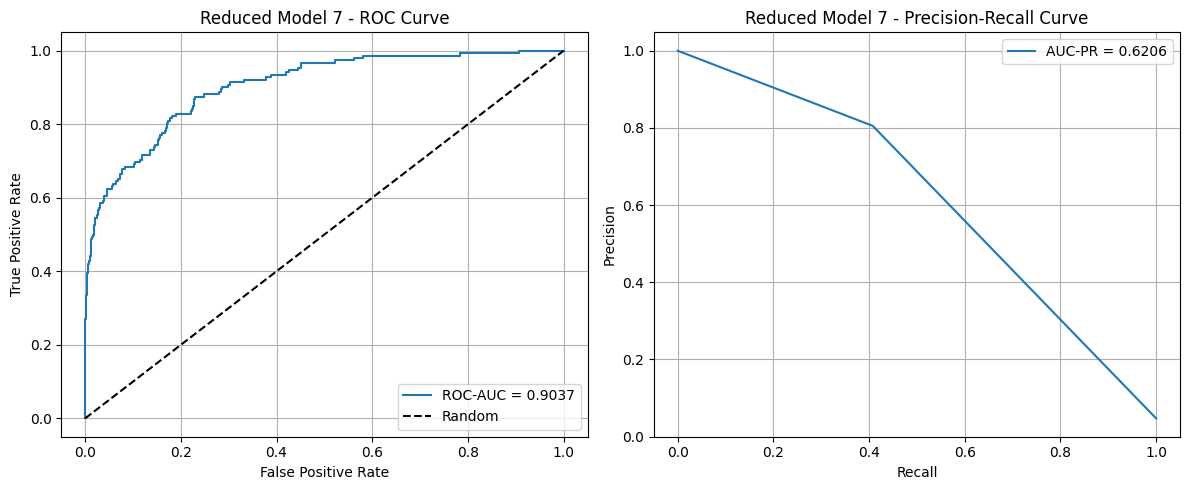

In [167]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced7 = stacking_model_reduced7.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced7)
roc_auc_reduced7 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced7)
auc_pr_reduced7 = auc(recall, precision)

mcc_reduced7 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced7)

print(f"ROC-AUC: {roc_auc_reduced7:.4f}")
print(f"AUC-PR: {auc_pr_reduced7:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced7:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced7:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 7 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced7:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 7 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Reduced 8 - Core + next 7 best (nc, sgd, etc, lda, xgb, bnb, dt)

In [168]:
# REDUCED MODEL 8
reduced8_models = [
    ('etcs', ExtraTreesClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('bnb', BernoulliNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

In [169]:
# Meta-learner
meta_learner = LogisticRegression()

In [170]:
# Stacking Classifier
stacking_model_reduced8 = StackingClassifier(estimators=reduced8_models, final_estimator=meta_learner, cv=5)

In [171]:
# Train model
stacking_model_reduced8.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etcs', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreeClassifier(random_state=42)),
                               ('lda',...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('bnb', BernoulliNB()),
                               ('dt', DecisionTreeClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [172]:
# Make predictions
y_pred_stack_reduced8 = stacking_model_reduced8.predict(X_test_rfe)

In [173]:
# Evaluating Reduced Model 8
accuracy_reduced8 = accuracy_score(y_test_rfe, y_pred_stack_reduced8)
conf_matrix_reduced8 = confusion_matrix(y_test_rfe, y_pred_stack_reduced8)
class_report_reduced8 = classification_report(y_test_rfe, y_pred_stack_reduced8)

TP = conf_matrix_reduced8[1, 1]
FN = conf_matrix_reduced8[1, 0]
FP = conf_matrix_reduced8[0, 1]
TN = conf_matrix_reduced8[0, 0]

TPR_reduced8 = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR_reduced8 = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy_reduced8 = (TPR_reduced8 + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("REDUCED MODEL 8 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB + DT (12 models)")
print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_reduced8:.4f}')
print(f'True Positive Rate (TPR): {TPR_reduced8:.4f}')
print(f'False Positive Rate (FPR): {FPR_reduced8:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_reduced8:.4f}')
print('\nClassification Report:')
print(class_report_reduced8)

REDUCED MODEL 8 - Core + NC + KNN + SGD + ETC + LDA + XGB + BNB + DT (12 models)
Evaluation Metrics:
Accuracy: 0.9672
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.7015

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



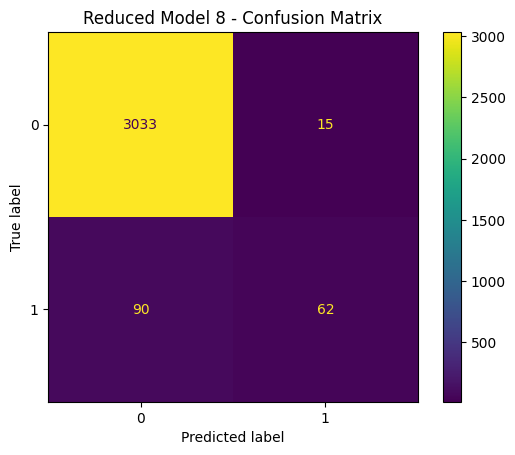

In [174]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_reduced8, display_labels=stacking_model_reduced8.classes_)
disp.plot()
plt.title('Reduced Model 8 - Confusion Matrix')
plt.show()

ROC-AUC: 0.9040
AUC-PR: 0.6206
Matthews Correlation Coefficient (MCC): 0.5593


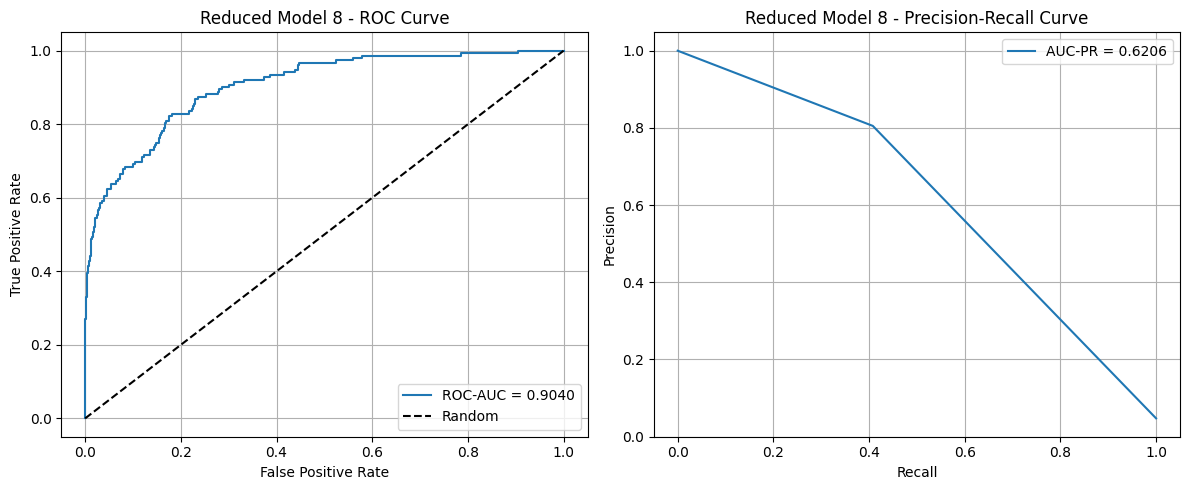

In [175]:
# ROC-AUC and AUC-PR
y_pred_proba_reduced8 = stacking_model_reduced8.predict_proba(X_test_rfe)[:, 1]
fpr, tpr, _ = roc_curve(y_test_rfe, y_pred_proba_reduced8)
roc_auc_reduced8 = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced8)
auc_pr_reduced8 = auc(recall, precision)

mcc_reduced8 = matthews_corrcoef(y_test_rfe, y_pred_stack_reduced8)

print(f"ROC-AUC: {roc_auc_reduced8:.4f}")
print(f"AUC-PR: {auc_pr_reduced8:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_reduced8:.4f}")

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_reduced8:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Reduced Model 8 - ROC Curve')
ax1.legend()
ax1.grid(True)

ax2.plot(recall, precision, label=f'AUC-PR = {auc_pr_reduced8:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Reduced Model 8 - Precision-Recall Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# SUMMARY COMPARISON

In [176]:
models_data = [
    ("Reduced 1 (Core)", 4, accuracy_reduced1, balanced_accuracy_reduced1, roc_auc_reduced1, auc_pr_reduced1, mcc_reduced1, TPR_reduced1, FPR_reduced1),
    ("Reduced 2 (Core+NC)", 5, accuracy_reduced2, balanced_accuracy_reduced2, roc_auc_reduced2, auc_pr_reduced2, mcc_reduced2, TPR_reduced2, FPR_reduced2),
    ("Reduced 3 (+SGD)", 6, accuracy_reduced3, balanced_accuracy_reduced3, roc_auc_reduced3, auc_pr_reduced3, mcc_reduced3, TPR_reduced3, FPR_reduced3),
    ("Reduced 4 (+ETC)", 7, accuracy_reduced4, balanced_accuracy_reduced4, roc_auc_reduced4, auc_pr_reduced4, mcc_reduced4, TPR_reduced4, FPR_reduced4),
    ("Reduced 5 (+LDA)", 8, accuracy_reduced5, balanced_accuracy_reduced5, roc_auc_reduced5, auc_pr_reduced5, mcc_reduced5, TPR_reduced5, FPR_reduced5),
    ("Reduced 6 (+XGB)", 9, accuracy_reduced6, balanced_accuracy_reduced6, roc_auc_reduced6, auc_pr_reduced6, mcc_reduced6, TPR_reduced6, FPR_reduced6),
    ("Reduced 7 (+BNB)", 10, accuracy_reduced7, balanced_accuracy_reduced7, roc_auc_reduced7, auc_pr_reduced7, mcc_reduced7, TPR_reduced7, FPR_reduced7),
    ("Reduced 8 (+DT)", 11, accuracy_reduced8, balanced_accuracy_reduced8, roc_auc_reduced8, auc_pr_reduced8, mcc_reduced8, TPR_reduced8, FPR_reduced8),
    ("Full Model", 12, accuracy_stack, balanced_accuracy, roc_auc_full, auc_pr, mcc_full, TPR, FPR)
]

In [177]:
# SUMMARY COMPARISON
print("SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON")
print("Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions")

print(f"{'Model':<25} {'N_Models':<10} {'Accuracy':<10} {'Bal_Acc':<10} {'ROC-AUC':<10} {'AUC-PR':<10} {'MCC':<8} {'TPR':<8} {'FPR':<8}")

for model_name, n_models, acc, bal_acc, roc_auc, auc_pr_score, mcc, tpr, fpr in models_data:
    print(f"{model_name:<25} {n_models:<10} {acc:<10.4f} {bal_acc:<10.4f} {roc_auc:<10.4f} {auc_pr_score:<10.4f} {mcc:<8.4f} {tpr:<8.4f} {fpr:<8.4f}")

# Find best performing models
best_accuracy = max(models_data, key=lambda x: x[2])
best_balanced = max(models_data, key=lambda x: x[3])
best_roc_auc = max(models_data, key=lambda x: x[4])
best_auc_pr = max(models_data, key=lambda x: x[5])
best_mcc = max(models_data, key=lambda x: x[6])
best_tpr = max(models_data, key=lambda x: x[7])
best_fpr = min(models_data, key=lambda x: x[8])

print("\nBEST PERFORMING MODELS:")
print(f"Best Accuracy: {best_accuracy[0]} - {best_accuracy[2]:.4f}")
print(f"Best Balanced Accuracy: {best_balanced[0]} - {best_balanced[3]:.4f}")
print(f"Best ROC-AUC: {best_roc_auc[0]} - {best_roc_auc[4]:.4f}")
print(f"Best AUC-PR: {best_auc_pr[0]} - {best_auc_pr[5]:.4f}")
print(f"Best MCC: {best_mcc[0]} - {best_mcc[6]:.4f}")
print(f"Best True Positive Rate (TPR): {best_tpr[0]} - {best_tpr[7]:.4f}")
print(f"Lowest False Positive Rate (FPR): {best_fpr[0]} - {best_fpr[8]:.4f}")

SYSTEMATIC REDUCED STACKING ENSEMBLE - SUMMARY COMPARISON
Threshold-based approach: Core performers (SHAP > 0.5) + incremental additions
Model                     N_Models   Accuracy   Bal_Acc    ROC-AUC    AUC-PR     MCC      TPR      FPR     
Reduced 1 (Core)          4          0.9663     0.6916     0.9054     0.6073     0.5424   0.3882   0.0049  
Reduced 2 (Core+NC)       5          0.9663     0.6947     0.9043     0.6065     0.5441   0.3947   0.0052  
Reduced 3 (+SGD)          6          0.9666     0.6949     0.9048     0.6117     0.5481   0.3947   0.0049  
Reduced 4 (+ETC)          7          0.9672     0.7015     0.9051     0.6206     0.5593   0.4079   0.0049  
Reduced 5 (+LDA)          8          0.9669     0.7013     0.9047     0.6154     0.5554   0.4079   0.0052  
Reduced 6 (+XGB)          9          0.9669     0.6982     0.9040     0.6162     0.5537   0.4013   0.0049  
Reduced 7 (+BNB)          10         0.9672     0.7015     0.9037     0.6206     0.5593   0.4079   0.0049  

# Precision-Recall Curves for All Models

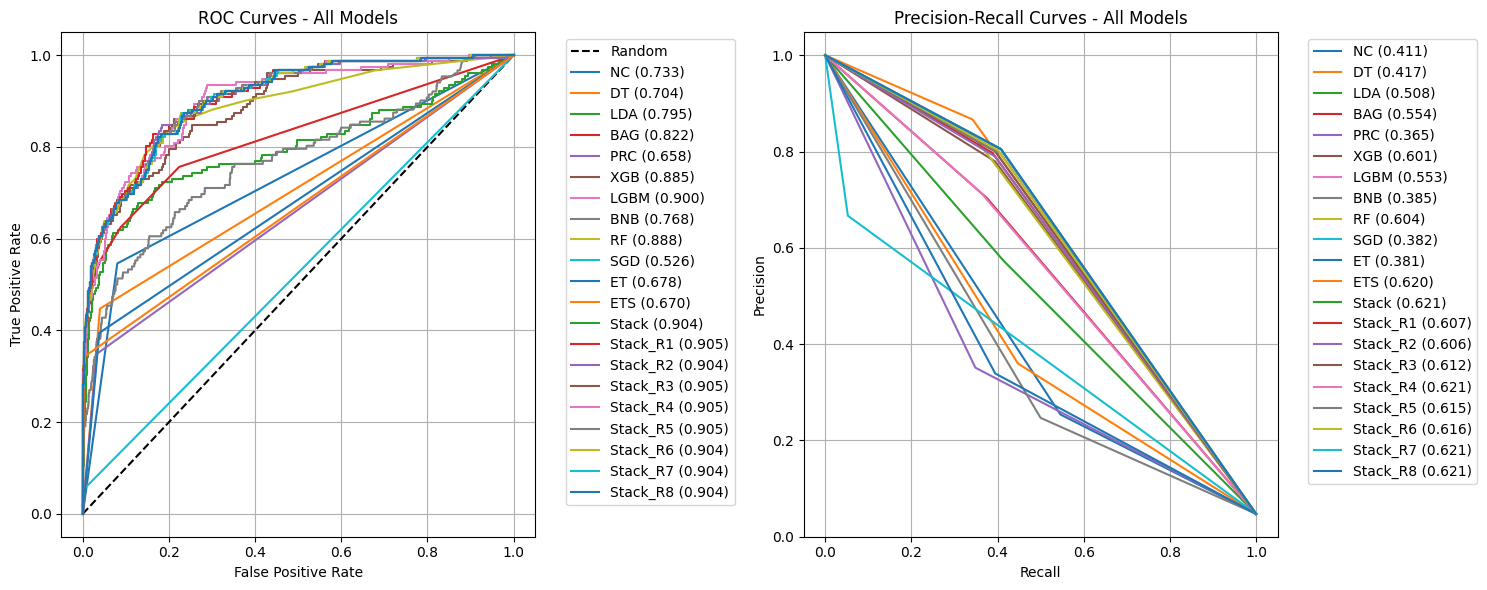

In [178]:
# Models
models = {
    'NC': y_pred_NC, 'DT': y_pred_DT, 'LDA': y_pred_LDA, 'BAG': y_pred_BAG,
    'PRC': y_pred_PRC, 'XGB': y_pred_XGB, 'LGBM': y_pred_LGBM, 'BNB': y_pred_BNB,
    'RF': y_pred_RF, 'SGD': y_pred_SGD, 'ET': y_pred_ET, 'ETS': y_pred_ETS,
    'Stack': y_pred_stack, 'Stack_R1': y_pred_stack_reduced1, 'Stack_R2': y_pred_stack_reduced2,
    'Stack_R3': y_pred_stack_reduced3, 'Stack_R4': y_pred_stack_reduced4, 'Stack_R5': y_pred_stack_reduced5,
    'Stack_R6': y_pred_stack_reduced6, 'Stack_R7': y_pred_stack_reduced7, 'Stack_R8': y_pred_stack_reduced8
}

# Plot ROC and PR curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot([0, 1], [0, 1], 'k--', label='Random')
for name, y_pred in models.items():
    if name == 'DT':
        y_scores = y_pred_proba_DT
    elif name == 'LDA':
        y_scores = y_pred_proba_LDA
    elif name == 'BAG':
        y_scores = y_pred_proba_BAG
    elif name == 'XGB':
        y_scores = y_pred_proba_XGB
    elif name == 'LGBM':
        y_scores = y_pred_proba_LGBM
    elif name == 'BNB':
        y_scores = y_pred_proba_BNB
    elif name == 'RF':
        y_scores = y_pred_proba_RF
    elif name == 'Stack':
        y_scores = y_pred_proba_full
    elif name == 'Stack_R1':
        y_scores = y_pred_proba_reduced1
    elif name == 'Stack_R2':
        y_scores = y_pred_proba_reduced2
    elif name == 'Stack_R3':
        y_scores = y_pred_proba_reduced3
    elif name == 'Stack_R4':
        y_scores = y_pred_proba_reduced4
    elif name == 'Stack_R5':
        y_scores = y_pred_proba_reduced5
    elif name == 'Stack_R6':
        y_scores = y_pred_proba_reduced6
    elif name == 'Stack_R7':
        y_scores = y_pred_proba_reduced7
    elif name == 'Stack_R8':
        y_scores = y_pred_proba_reduced8
    else:
        y_scores = y_pred
    
    fpr, tpr, _ = roc_curve(y_test_rfe, y_scores)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} ({roc_auc:.3f})')

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves - All Models')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True)

for name, y_pred in models.items():
    precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred)
    auc_pr = auc(recall, precision)
    ax2.plot(recall, precision, label=f'{name} ({auc_pr:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves - All Models')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [181]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, matthews_corrcoef
from scipy.stats import ttest_rel

# Ensure X_train_rfe and y_train_rfe are NumPy arrays
X = X_train_rfe.values if isinstance(X_train_rfe, pd.DataFrame) else X_train_rfe
y = y_train_rfe.values if isinstance(y_train_rfe, pd.Series) else y_train_rfe

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to compute fold-wise scores for a given model and metric
def get_cv_scores(model, X, y, metric, proba=False):
    scores = []
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        if proba:
            # Handle models without predict_proba
            if hasattr(model, "predict_proba"):
                y_pred = model.predict_proba(X[test_idx])[:, 1]
            else:
                # Use calibrated probabilities
                calib_model = CalibratedClassifierCV(model, cv="prefit")
                calib_model.fit(X[train_idx], y[train_idx])
                y_pred = calib_model.predict_proba(X[test_idx])[:, 1]
        else:
            y_pred = model.predict(X[test_idx])
        scores.append(metric(y[test_idx], y_pred))
    return np.array(scores)

# Base learners included in Reduced-4
base_models = {
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "NearestCentroid": NearestCentroid(),
    "SGD": SGDClassifier(loss='log_loss', random_state=42),
    "ExtraTree": ExtraTreeClassifier(random_state=42)
}

# Collect base learner results
results_aucpr = {}
results_mcc = {}
for name, model in base_models.items():
    results_aucpr[name] = get_cv_scores(model, X, y, average_precision_score, proba=True)
    results_mcc[name] = get_cv_scores(model, X, y, matthews_corrcoef, proba=False)

# Reduced-4 ensemble results
aucpr_reduced4 = get_cv_scores(stacking_model_reduced4, X, y, average_precision_score, proba=True)
mcc_reduced4 = get_cv_scores(stacking_model_reduced4, X, y, matthews_corrcoef, proba=False)

# Run paired t-tests (Reduced-4 vs each base learner)
rows = []
for name in base_models.keys():
    # AUC-PR comparison
    t_stat, p_val = ttest_rel(aucpr_reduced4, results_aucpr[name])
    rows.append(["AUC-PR", f"Reduced-4 vs {name}", t_stat, p_val])

    # MCC comparison
    t_stat, p_val = ttest_rel(mcc_reduced4, results_mcc[name])
    rows.append(["MCC", f"Reduced-4 vs {name}", t_stat, p_val])

# Save results into a DataFrame for easier reporting
df_results = pd.DataFrame(rows, columns=["Metric", "Comparison", "t-value", "p-value"])
print("\n[Statistical Validation - Reduced-4 vs Base Learners]")
print(df_results)

[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3804
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3806
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info] 